# Spectral Pollution for Top Forms

### Benchmarking finite element discretisations of the magnetic advection–diffusion eigenvalue problem at $k = n = 2$

---

This notebook benchmarks four discretisations of the magnetic advection–diffusion
eigenvalue problem for **top forms** — differential $n$-forms in dimension $n$, here
$k = n = 2$ on $\Omega = (0,\pi)^2$. It is the $k=n$ companion to
`MHD_Spectral_Tutorial.ipynb`, which treats 1-forms; the solver architecture is shared,
but every function space and every weak form is different.

Top forms are the degenerate end of the de Rham complex, and that degeneracy is what
makes them interesting:

* the closedness constraint $\mathrm{d}^n u = 0$ holds **identically**, so the Lagrange
  multiplier $p$ of the general $B$-formulation simply disappears;
* what is left is a genuine two-field saddle point in the *total flux*
  $\sigma := \varepsilon\,\delta^n u + \iota^n_\beta u$, in which the auxiliary variable
  absorbs the advection;
* and because the constraint is vacuous, inf–sup stability alone no longer protects
  against spectral pollution. This notebook exhibits a conforming, inf–sup stable pair
  that pollutes.

**The four setups**

| Tag | Spaces | Status |
|:--|:--|:--|
| `A(CG)` | $\mathrm{CG}_r \cap H^1_0$ | primal reduction; FEEC-conforming |
| `B(RT)`, `B(BDM)` | $\mathcal{P}^-_r\Lambda^1\times\mathcal{P}^-_r\Lambda^2$, $\mathcal{P}_r\Lambda^1\times\mathcal{P}_r\Lambda^2$ | mixed, unshifted |
| `σ(RT)`, `σ(BDM)` | as above | shifted total-flux formulation |
| `σ(P1–divP1)` | $\Sigma_h = [P_1]^2$, $V_h = \operatorname{div}\Sigma_h$ | **the trap** (Boffi–Brezzi–Gastaldi) |

**Contents**

1. [The top-form eigenvalue problem](#1)
2. [Meshes: the criss-cross grid](#2)
3. [Velocity fields](#3)
4. [The four discretisations](#4)
5. [The eigensolver and the matching pipeline](#5)
6. [Experiment I — the diffusive limit $\beta = 0$](#6)
7. [Experiment II — the advective regime $\beta \neq 0$](#7)
8. [Summary](#8)

<a id="0"></a>
## 0. Setup

In [1]:
from __future__ import annotations

import itertools
from dataclasses import dataclass, field
from pathlib import Path
from typing import Callable, Optional

import numpy as np
import pandas as pd
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import scipy.linalg as sla
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from firedrake import *
from firedrake.function import PointEvaluator
from firedrake.pyplot import triplot, tripcolor

from petsc4py import PETSc
from slepc4py import SLEPc

# The epsilon-pseudospectrum machinery lives in its own module: it works on
# assembled PETSc matrices and knows nothing about the formulation, so the same
# code serves this benchmark and the 1-form baseline.
import pseudospectra_partial_schur as ps

# `from firedrake import *` shadows the standard-library `logging`; re-import it
# under another name and silence the one warning `triplot` provokes on every call.
import logging as stdlogging
stdlogging.getLogger("firedrake").addFilter(
    lambda record: "is empty. This is likely an error" not in record.getMessage())

FIGDIR = Path("figures"); FIGDIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "font.family": "serif", "mathtext.fontset": "cm",
    "font.size": 11, "axes.titlesize": 11, "axes.labelsize": 11,
    "figure.dpi": 110, "savefig.bbox": "tight", "savefig.pad_inches": 0.02,
    "axes.linewidth": 0.6,
})

L_DOMAIN = np.pi          # Omega = (0, L)^2


# --- table rendering, without the jinja2 dependency of pandas' .style --------
def _cell(value, spec):
    if value is None:
        return "--"
    if isinstance(value, complex):
        return (f"{value.real:.5f}{value.imag:+.5f}i" if abs(value.imag) > 1e-10
                else spec.format(value.real))
    try:
        return "--" if not np.isfinite(value) else spec.format(value)
    except (TypeError, ValueError):
        return str(value)


def fmt_table(df, caption=None, default="{:.6f}", rules=(), row_rules=()):
    """Format a DataFrame for display.

    `rules` is a list of (column-name-substring, format spec); `row_rules` the
    same for index labels, and takes precedence -- tables here sometimes carry a
    condition-number *row* rather than a column.
    """
    def spec_for(key, table):
        name = " ".join(map(str, key)) if isinstance(key, tuple) else str(key)
        # Exact matches win over substring matches, so a rule keyed on a short
        # name cannot capture a longer column that happens to contain it.
        return next((spec for k, spec in table if k == name),
                    next((spec for k, spec in table if k in name), None))

    out = pd.DataFrame(
        {col: [_cell(v, spec_for(idx, row_rules) or spec_for(col, rules) or default)
               for idx, v in zip(df.index, df[col])]
         for col in df.columns}, index=df.index)
    if caption:
        display(Markdown(f"**{caption}**"))
    return out


print(f"PETSc scalars: {PETSc.ScalarType.__name__}")

PETSc scalars: float64


<a id="1"></a>
## 1. The top-form eigenvalue problem

### 1.1 The rotated complex and its proxies

In two dimensions the Hodge star rotates a 1-form into a 1-form, so $\mathbb{R}^2$ carries
*two* parallel de Rham complexes. Top forms live naturally in the **rotated**, or
$H(\operatorname{div})$, sequence (Table 2.3 of the dissertation):

$$
\mathbb{R}\;\hookrightarrow\;H^1(\Omega)\;\xrightarrow{\ \operatorname{curl}\ }\;H(\operatorname{div},\Omega)\;\xrightarrow{\ \operatorname{div}\ }\;L^2(\Omega)\;\to\;0 ,
$$

with the dictionary

| $k$ | $\Lambda^k$ | $H\Lambda^k$ | $H^*\Lambda^k$ | $\mathrm{d}^k$ | $\delta^k$ |
|:--|:--|:--|:--|:--|:--|
| 0 | scalar | $H^1$ | $L^2$ | $\operatorname{curl}$ | $0$ |
| 1 | vector | $H(\operatorname{div})$ | $H(\operatorname{rot})$ | $\operatorname{div}$ | $\operatorname{rot}$ |
| **2** | **scalar** | $L^2$ | $H^1$ | $0$ | $-\operatorname{grad}$ |

So for $k = n = 2$ the unknown $u$ is a **scalar** (the out-of-plane magnetic field
component), $\mathrm{d}^n = 0$ identically, and $\delta^n = -\nabla$.

The remaining ingredient is the contraction. For $u = \tilde u\,\mathrm{d}x\wedge\mathrm{d}y$
and $\beta = \beta_1\partial_x + \beta_2\partial_y$,

$$
\iota_\beta\,(\mathrm{d}x\wedge\mathrm{d}y) \;=\; \beta_1\,\mathrm{d}y - \beta_2\,\mathrm{d}x ,
$$

and since the $H(\operatorname{div})$ proxy of $a\,\mathrm{d}x + b\,\mathrm{d}y$ is the vector
$(b,-a)$ — the identification for which $\mathrm{d}^1$ becomes $\operatorname{div}$ — the
proxy of $\iota^n_\beta u$ is simply

$$
\boxed{\;\iota^n_\beta u \;\longleftrightarrow\; u\,\beta\;}
$$

a scalar field times the velocity. That is the whole reason top forms are easy to
implement and hard to discretise: the advection term is an ordinary product, and the
constraint that usually stabilises the mixed system is gone.

### 1.2 The equation

Substituting into the half-Hodge eigenvalue problem (2.25) of the dissertation,

$$
\varepsilon\,\mathrm{d}^{n-1}\delta^n u + \mathrm{d}^{n-1}\iota^n_\beta u = \lambda u ,
$$

gives the scalar **advection–diffusion eigenvalue problem**

$$
\boxed{\;-\varepsilon\,\Delta u \;+\; \nabla\!\cdot(\beta\,u) \;=\; \lambda\,u \quad\text{in }\Omega,
\qquad u = 0 \ \text{ on }\partial\Omega, \qquad \varepsilon = R_m^{-1}. \;}
$$

The boundary condition is the FEEC one: $u \in \mathring{H}^*\Lambda^n(\Omega)$ means
$\operatorname{Tr}(\star u) = 0$, and $\star u$ is a $0$-form, so this is exactly $u|_{\partial\Omega}=0$.

### 1.3 Exact reference data

Three facts pin the benchmark down.

**(i) Diffusive limit.** For $\beta = 0$ the operator is $-\varepsilon\Delta$ with Dirichlet
data, so on $\Omega=(0,\pi)^2$

$$
\lambda_{mn} \;=\; \varepsilon\,(m^2+n^2), \qquad m,n \ge 1,
$$

i.e. $\varepsilon\cdot\{2,5,5,8,10,10,13,13,17,17,18,20,20,25,\dots\}$, exact to every digit.

**(ii) Constant wind.** For constant $\beta$ the substitution
$u = e^{\,\beta\cdot x/(2\varepsilon)}w$ removes the advection term exactly and leaves
$-\varepsilon\Delta w + \tfrac{|\beta|^2}{4\varepsilon}w = \lambda w$ with $w \in H^1_0$. Hence

$$
\boxed{\;\lambda_{mn} \;=\; \varepsilon(m^2+n^2) \;+\; \frac{|\beta|^2}{4\varepsilon}\;}
$$

— a *rigid shift* of the whole spectrum. This is the sharpest diagnostic in the notebook:
every genuine eigenvalue must move by exactly $|\beta|^2/4\varepsilon$, and anything that
does not is not approximating an eigenvalue at all.

**(iii) Two structural theorems.** For divergence-free $\beta$ the advection term is
skew in the Rayleigh quotient, so $\operatorname{Re}\lambda \ge 2\varepsilon > 0$: no
two-dimensional dynamo (Zeldovich, Theorem 4). And if $\beta = \nabla\phi$ is a potential
field the operator is conjugate to a non-negative self-adjoint one, so the spectrum is
**real** (King, Theorem 7). Both are checked numerically in Section 7.

<a id="2"></a>
## 2. Meshes: the criss-cross grid

Every experiment runs on the **criss-cross** (Union-Jack) mesh: each square of an
$N\times N$ grid is split by *both* diagonals into four triangles, giving $4N^2$ cells and
one interior vertex per square. The pathological element of Section 4.4 is only
pathological on this mesh, so it is the common ground for all four discretisations.

In [2]:
def crisscross_mesh(N, L=L_DOMAIN):
    r"""Criss-cross triangulation of $(0,L)^2$: $4N^2$ cells, $h = L/N$.

    `diagonal="crossed"` is Firedrake's spelling of the Union-Jack pattern -- it
    inserts a centre vertex in every grid square and cuts both diagonals.  The
    resulting mesh is symmetric under all eight symmetries of the square, which
    matters here: the spurious mode of Section 4.4 is a checkerboard pattern
    living on exactly this structure.
    """
    return SquareMesh(N, N, L, quadrilateral=False, diagonal="crossed")

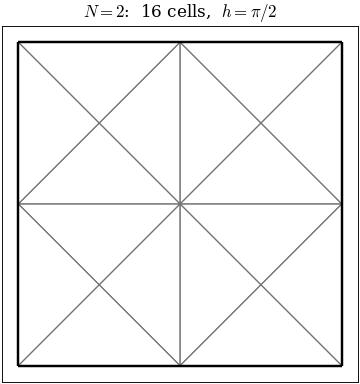

In [3]:
mesh = crisscross_mesh(2)
markers = mesh.exterior_facets.unique_markers

fig, ax = plt.subplots(figsize=(4.2, 4.2))
# `interior_kw` reaches a PolyCollection, so it wants `edgecolors` (passing
# `color` would fill the cells); `boundary_kw["colors"]` is zipped against the
# marker list, so it needs one entry per marker.
triplot(mesh, axes=ax,
        interior_kw={"linewidths": 0.7, "edgecolors": "0.45"},
        boundary_kw={"linewidths": 1.6, "colors": ["k"] * len(markers)})
ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
ax.set_title(rf"$N = 2$:  {mesh.num_cells()} cells,  $h = \pi/2$")
fig.savefig(FIGDIR / "topform_mesh_N2.pdf")
plt.show()

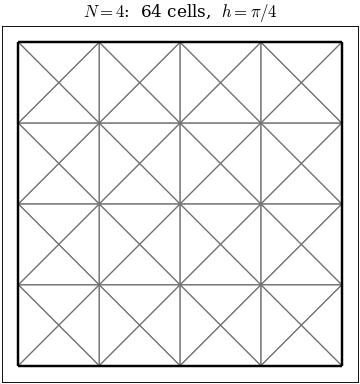

In [4]:
mesh = crisscross_mesh(4)
markers = mesh.exterior_facets.unique_markers

fig, ax = plt.subplots(figsize=(4.2, 4.2))
# `interior_kw` reaches a PolyCollection, so it wants `edgecolors` (passing
# `color` would fill the cells); `boundary_kw["colors"]` is zipped against the
# marker list, so it needs one entry per marker.
triplot(mesh, axes=ax,
        interior_kw={"linewidths": 0.7, "edgecolors": "0.45"},
        boundary_kw={"linewidths": 1.6, "colors": ["k"] * len(markers)})
ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
ax.set_title(rf"$N = 4$:  {mesh.num_cells()} cells,  $h = \pi/4$")
fig.savefig(FIGDIR / "topform_mesh_N4.pdf")
plt.show()

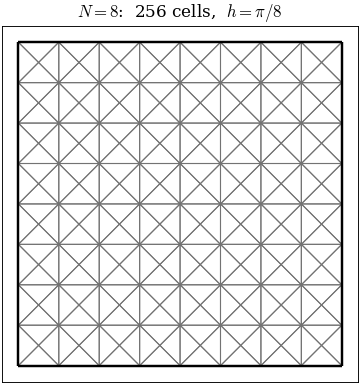

In [5]:
mesh = crisscross_mesh(8)
markers = mesh.exterior_facets.unique_markers

fig, ax = plt.subplots(figsize=(4.2, 4.2))
# `interior_kw` reaches a PolyCollection, so it wants `edgecolors` (passing
# `color` would fill the cells); `boundary_kw["colors"]` is zipped against the
# marker list, so it needs one entry per marker.
triplot(mesh, axes=ax,
        interior_kw={"linewidths": 0.7, "edgecolors": "0.45"},
        boundary_kw={"linewidths": 1.6, "colors": ["k"] * len(markers)})
ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
ax.set_title(rf"$N = 8$:  {mesh.num_cells()} cells,  $h = \pi/8$")
fig.savefig(FIGDIR / "topform_mesh_N8.pdf")
plt.show()

<a id="3"></a>
## 3. Velocity fields

Four fields from Table 4.1 of the dissertation, chosen so that each isolates one
structural property. Recall from Section 1.3 that a *potential* field forces a real
spectrum, and a *solenoidal* field forces $\operatorname{Re}\lambda>0$.

| Tag | $\beta$ | Regularity | $\beta = \nabla\phi$ | $\nabla\!\cdot\beta = 0$ | What it tests |
|:--|:--|:--|:--:|:--:|:--|
| `b0` | $(0,0)$ | $C^\infty$ | yes | yes | the exact Dirichlet spectrum |
| `b1` | $(1,1)$ | $C^\infty$ | yes | yes | the exact rigid shift; King's theorem |
| `b4` | $(-(y-\tfrac{\pi}{2}),\,x-\tfrac{\pi}{2})$ | $C^\infty$ | no | yes | rotation: complex spectrum |
| `b7` | $(\operatorname{sign}(y-\tfrac{\pi}{2}),\,0)$ | $L^\infty\setminus W^{1,\infty}$ | no | yes | discontinuous shear |

`b7` is the case the theory is built for: Lemmas 2–4 of the dissertation assume only
$\beta \in L^\infty(\Omega)$, and a Heaviside shear is exactly a field that is bounded
without being Lipschitz. Note $\partial_x(\operatorname{sign}(y-y_0)) = 0$, so it is
solenoidal despite the jump.

In [6]:
@dataclass(frozen=True)
class Wind:
    """A named background field, built lazily on a given mesh."""
    key: str
    tex: str
    note: str
    potential: bool           # beta = grad(phi)?  -> real spectrum (King)
    sup: float                # ||beta||_Linf, used for the shift nu of Lemma 4
    _build: Callable

    def __call__(self, mesh, L=L_DOMAIN):
        return self._build(mesh, L)


def _centre(mesh, L):
    x, y = SpatialCoordinate(mesh)
    return x - Constant(L / 2), y - Constant(L / 2)


WINDS = {
    "b0": Wind("b0", r"$\beta=(0,0)$", "no wind", True, 0.0,
               lambda mesh, L: None),
    "b1": Wind("b1", r"$\beta=(1,1)$", "uniform potential field", True, np.sqrt(2),
               lambda mesh, L: as_vector([Constant(1.0), Constant(1.0)])),
    "b4": Wind("b4", r"$\beta=(-\hat y,\ \hat x)$", "rigid rotation", False,
               np.pi / np.sqrt(2),
               lambda mesh, L: as_vector([-_centre(mesh, L)[1], _centre(mesh, L)[0]])),
    # NB: matplotlib's mathtext has no \tfrac, and these labels go into figure
    # titles as well as into markdown -- keep them to the common subset.
    "b7": Wind("b7", r"$\beta=(\mathrm{sign}(y-\frac{\pi}{2}),\ 0)$",
               "Heaviside shear", False, 1.0,
               lambda mesh, L: as_vector(
                   [conditional(gt(SpatialCoordinate(mesh)[1], Constant(L / 2)),
                                1.0, -1.0), Constant(0.0)])),
}

In [7]:
def sample_grid(f, mesh, n=15, pad=0.06):
    """Evaluate a vector `Function` on a regular n x n grid over the mesh bbox."""
    coords = mesh.coordinates.dat.data_ro
    (x0, y0), (x1, y1) = coords.min(axis=0), coords.max(axis=0)
    dx, dy = pad * (x1 - x0), pad * (y1 - y0)
    X, Y = np.meshgrid(np.linspace(x0 + dx, x1 - dx, n),
                       np.linspace(y0 + dy, y1 - dy, n))
    pts = np.column_stack([X.ravel(), Y.ravel()])
    # A tight tolerance: the default is inherited from the mesh (0.5 in reference
    # coordinates) and is loose enough to snap exterior points into boundary cells.
    vals = np.asarray(PointEvaluator(mesh, pts, missing_points_behaviour="ignore",
                                     tolerance=1e-6).evaluate(f))
    return X, Y, vals[:, 0].reshape(X.shape), vals[:, 1].reshape(X.shape)

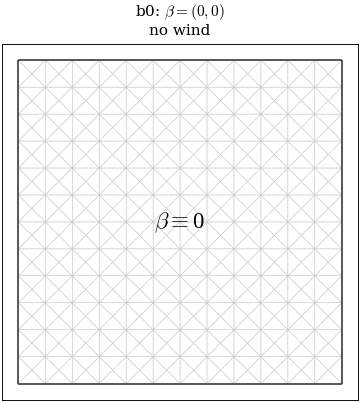

In [8]:
mesh_w = crisscross_mesh(12)
markers = mesh_w.exterior_facets.unique_markers

fig, ax = plt.subplots(figsize=(4.2, 4.2))
triplot(mesh_w, axes=ax, interior_kw={"linewidths": 0.3, "edgecolors": "0.8"},
        boundary_kw={"linewidths": 1.2, "colors": ["0.3"] * len(markers)})
ax.text(0.5, 0.5, r"$\beta\equiv 0$", ha="center", va="center",
        transform=ax.transAxes, fontsize=15)
ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
ax.set_title("b0: " + WINDS["b0"].tex + "\n" + WINDS["b0"].note, fontsize=10)
fig.savefig(FIGDIR / "topform_wind_b0.pdf")
plt.show()

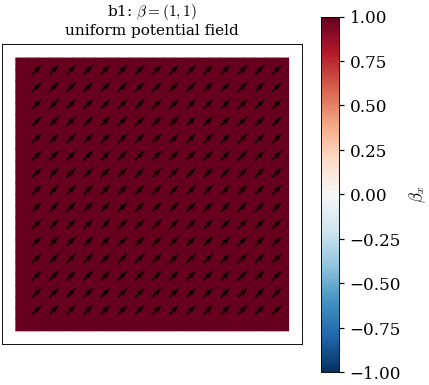

In [9]:
mesh_w = crisscross_mesh(12)
beta_w = WINDS["b1"](mesh_w)

# DG0 keeps the jump in b7 a jump; the quadrature sees the exact sign().
bx = Function(FunctionSpace(mesh_w, "DG", 0)).interpolate(beta_w[0])
lim = float(np.abs(bx.dat.data_ro).max()) or 1.0

bf = Function(VectorFunctionSpace(mesh_w, "CG", 1)).project(beta_w)
X, Y, U, V = sample_grid(bf, mesh_w)
speed = np.nanmax(np.hypot(U, V)) or 1.0
step = float(X[0, 1] - X[0, 0])

fig, ax = plt.subplots(figsize=(4.4, 4.2))
art = tripcolor(bx, axes=ax, cmap="RdBu_r", vmin=-lim, vmax=lim)
ax.quiver(X, Y, U, V, color="k", angles="xy", scale_units="xy",
          scale=speed / (0.8 * step), width=0.006, alpha=0.85)
ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
ax.set_title("b1: " + WINDS["b1"].tex + "\n" + WINDS["b1"].note, fontsize=10)
fig.colorbar(art, ax=ax, label=r"$\beta_x$")
fig.savefig(FIGDIR / "topform_wind_b1.pdf")
plt.show()

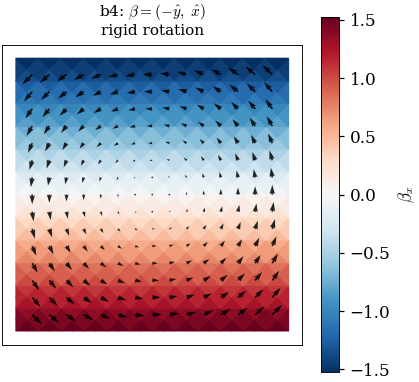

In [10]:
mesh_w = crisscross_mesh(12)
beta_w = WINDS["b4"](mesh_w)

# DG0 keeps the jump in b7 a jump; the quadrature sees the exact sign().
bx = Function(FunctionSpace(mesh_w, "DG", 0)).interpolate(beta_w[0])
lim = float(np.abs(bx.dat.data_ro).max()) or 1.0

bf = Function(VectorFunctionSpace(mesh_w, "CG", 1)).project(beta_w)
X, Y, U, V = sample_grid(bf, mesh_w)
speed = np.nanmax(np.hypot(U, V)) or 1.0
step = float(X[0, 1] - X[0, 0])

fig, ax = plt.subplots(figsize=(4.4, 4.2))
art = tripcolor(bx, axes=ax, cmap="RdBu_r", vmin=-lim, vmax=lim)
ax.quiver(X, Y, U, V, color="k", angles="xy", scale_units="xy",
          scale=speed / (0.8 * step), width=0.006, alpha=0.85)
ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
ax.set_title("b4: " + WINDS["b4"].tex + "\n" + WINDS["b4"].note, fontsize=10)
fig.colorbar(art, ax=ax, label=r"$\beta_x$")
fig.savefig(FIGDIR / "topform_wind_b4.pdf")
plt.show()

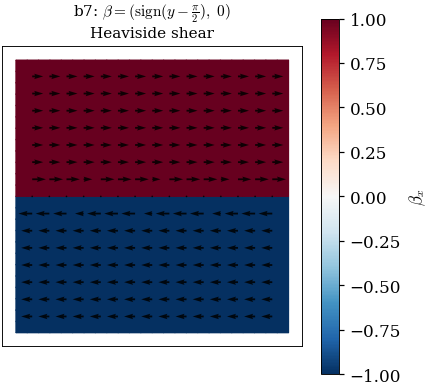

In [11]:
mesh_w = crisscross_mesh(12)
beta_w = WINDS["b7"](mesh_w)

# DG0 keeps the jump in b7 a jump; the quadrature sees the exact sign().
bx = Function(FunctionSpace(mesh_w, "DG", 0)).interpolate(beta_w[0])
lim = float(np.abs(bx.dat.data_ro).max()) or 1.0

bf = Function(VectorFunctionSpace(mesh_w, "CG", 1)).project(beta_w)
X, Y, U, V = sample_grid(bf, mesh_w)
speed = np.nanmax(np.hypot(U, V)) or 1.0
step = float(X[0, 1] - X[0, 0])

fig, ax = plt.subplots(figsize=(4.4, 4.2))
art = tripcolor(bx, axes=ax, cmap="RdBu_r", vmin=-lim, vmax=lim)
ax.quiver(X, Y, U, V, color="k", angles="xy", scale_units="xy",
          scale=speed / (0.8 * step), width=0.006, alpha=0.85)
ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
ax.set_title("b7: " + WINDS["b7"].tex + "\n" + WINDS["b7"].note, fontsize=10)
fig.colorbar(art, ax=ax, label=r"$\beta_x$")
fig.savefig(FIGDIR / "topform_wind_b7.pdf")
plt.show()

<a id="4"></a>
## 4. The four discretisations

### 4.1 `A(CG)` — the primal reduction

Testing $\varepsilon\,\mathrm{d}^{n-1}\delta^n u + \mathrm{d}^{n-1}\iota^n_\beta u = \lambda u$
against $v \in \mathring{H}^*\Lambda^n = H^1_0$ and integrating by parts once gives, in
proxies,

$$
\varepsilon\,(\nabla u, \nabla v) \;-\; (\beta u,\ \nabla v) \;=\; \lambda\,(u,v)
\qquad \forall v \in H^1_0(\Omega).
$$

This is Section 4.2.1 of the dissertation. It is worth being explicit about what has
happened: **at $k=n$ the mixed $B$-formulation (3.2) collapses onto a single-field
Lagrange discretisation**, because the multiplier space $\Lambda^{k+1}$ is empty and the
$H^*$-conforming space at $k=n$ is $H^1$. So `A(CG)` here is the primal reduction, not
the $H(\operatorname{div})$-potential formulation of Section 3.1.3 — that one would put
$\omega \in H\Lambda^{n-1}$ with $u = \operatorname{div}\omega$ and is a different object.
The boundary condition is imposed **essentially**, as a `DirichletBC`.

In [12]:
def primal_pencil(mesh, degree=1, beta=None, eps=Constant(1.0), nu=0.0):
    r"""`A(CG)`: $\varepsilon(\nabla u,\nabla v) - (\beta u,\nabla v) = \lambda(u,v)$."""
    V = FunctionSpace(mesh, "CG", degree)
    u, v = TrialFunction(V), TestFunction(V)

    a = eps * inner(grad(u), grad(v)) * dx
    if beta is not None:
        a -= inner(u * beta, grad(v)) * dx        # iota^n_beta u  <->  u * beta
    if nu:
        a += Constant(nu) * inner(u, v) * dx

    bcs = [DirichletBC(V, Constant(0.0), "on_boundary")]
    # `weight=0.0` puts 0 (not 1) on the constrained diagonal of M, so the
    # boundary rows contribute eigenvalues at infinity rather than at lambda = 1.
    A = assemble(a, bcs=bcs).petscmat
    M = assemble(inner(u, v) * dx, bcs=bcs, weight=0.0).petscmat
    return A, M, V, None

### 4.2 `B(RT)`, `B(BDM)` — the mixed total-flux system

Introduce the **total flux**, the variable that carries the diffusive and the advective
transport together:

$$
\sigma \;:=\; \varepsilon\,\delta^n u \;+\; \iota^n_\beta u
\qquad\longleftrightarrow\qquad
\sigma \;=\; u\beta - \varepsilon\nabla u \;\in\; H(\operatorname{div},\Omega).
$$

Rearranging and testing against $\tau \in H\Lambda^{n-1}$, the generalised Green formula
$(\delta^n u, \tau) = (u, \mathrm{d}^{n-1}\tau) - \int_{\partial\Omega}\operatorname{Tr}(\bar\tau)\wedge\operatorname{Tr}(\star u)$
kills the boundary term *because* $\operatorname{Tr}(\star u)=0$. The result is
equation (3.5): find $(\sigma,u) \in H\Lambda^{n-1}\times L^2\Lambda^n$ with

$$
\begin{cases}
\bigl(\varepsilon^{-1}\sigma,\tau\bigr) - \bigl(\varepsilon^{-1}\iota^n_\beta u,\tau\bigr) - \bigl(u,\mathrm{d}^{n-1}\tau\bigr) = 0 & \forall \tau \in H\Lambda^{n-1},\\[2pt]
\bigl(\mathrm{d}^{n-1}\sigma,\ v\bigr) = \lambda (u,v) & \forall v \in L^2\Lambda^n .
\end{cases}
$$

**The Dirichlet condition is now natural**: nothing is imposed on $\Sigma_h$, and
$u|_{\partial\Omega}=0$ emerges from the first equation. That inversion — essential in
`A(CG)`, natural here — is the practical difference between the two formulations.

The discrete pair must be a de Rham subcomplex, $\mathrm{d}^{n-1}\Lambda_h^{n-1}\subseteq\Lambda_h^n$
(Lemma 4 leans on exactly this). Table 2.4 gives the two admissible families in 2D:

$$
\text{trimmed:}\quad \mathcal{P}^-_r\Lambda^1\times\mathcal{P}^-_r\Lambda^2 = \mathrm{RT}_r\times\mathrm{DG}_{r-1},
\qquad
\text{full:}\quad \mathcal{P}_r\Lambda^1\times\mathcal{P}_r\Lambda^2 = \mathrm{BDM}_r\times\mathrm{DG}_{r-1}.
$$

### 4.3 `σ(RT)`, `σ(BDM)` — the shifted formulation

Lemma 3 of the dissertation establishes the continuous inf–sup condition only for a
**shifted** bilinear form, adding $\nu(u,v)$ to both sides:

$$
\mathcal{B}\bigl((\sigma,u),(\tau,v)\bigr) := \bigl(\varepsilon^{-1}\sigma,\tau\bigr) - \bigl(\varepsilon^{-1}\iota^n_\beta u,\tau\bigr) - \bigl(u,\mathrm{d}^{n-1}\tau\bigr) + \bigl(\mathrm{d}^{n-1}\sigma,v\bigr) + \nu(u,v) = \tilde\lambda\,(u,v),
$$

with $\tilde\lambda = \lambda + \nu$ and $\nu \ge 2C^2\|\beta\|_{L^\infty}^2/\varepsilon + 2$
(Lemma 4). The shift is what makes the *source* problem well posed — it buys the
coercivity in (3.13) — and it is **spectrally inert**: $\tilde\lambda-\nu$ reproduces
$\lambda$ to machine precision, which Section 6 verifies. So `B(...)` and `σ(...)` are the
same discretisation seen through a shifted lens; both are included because the shift is
what the theory needs and it costs nothing to carry.

In [13]:
def nu_min(beta_sup, eps, C=1.0):
    r"""The shift of Lemma 4: $\nu \ge 2C^2\|\beta\|_\infty^2/\varepsilon + 2$.

    Remark 1 gives $\|\iota^n_\beta u\|_{L^2}\le\|\beta\|_{L^\infty}\|u\|_{L^2}$ for
    top forms, so $C=1$ is admissible.
    """
    return 2.0 * C**2 * beta_sup**2 / float(eps) + 2.0


def mixed_pencil(mesh, family="RT", degree=1, beta=None, eps=Constant(1.0), nu=0.0):
    r"""`B(...)` / `σ(...)`: the total-flux saddle point on $\Sigma_h \times V_h$.

    `family` is "RT" (trimmed) or "BDM" (full); both pair with $\mathrm{DG}_{r-1}$,
    which is what makes $\mathrm{d}^{n-1}\Sigma_h = V_h$ exactly.  No boundary
    condition is applied anywhere: $u|_{\partial\Omega}=0$ is natural here.
    """
    W = FunctionSpace(mesh, family, degree) * FunctionSpace(mesh, "DG", degree - 1)
    (s, u) = TrialFunctions(W)
    (t, v) = TestFunctions(W)

    a = ((1 / eps) * inner(s, t) * dx          # (eps^-1 sigma, tau)
         - inner(u, div(t)) * dx               # -(u, d^{n-1} tau)
         + inner(div(s), v) * dx)              # +(d^{n-1} sigma, v)
    if beta is not None:
        a -= (1 / eps) * inner(u * beta, t) * dx   # -(eps^-1 iota_beta u, tau)
    if nu:
        a += Constant(nu) * inner(u, v) * dx       # the shift of Lemma 3

    # The mass form touches only the u block: M is singular by construction, and
    # the sigma block supplies dim(Sigma_h) eigenvalues at infinity.
    return assemble(a).petscmat, assemble(inner(u, v) * dx).petscmat, W, None

### 4.4 `σ(P1–divP1)` — the trap

Now the pathological pair of Boffi, Brezzi and Gastaldi (2000). Keep the very same
bilinear form and change only the spaces:

$$
\Sigma_h = [P_1]^2 \subset H(\operatorname{div},\Omega),
\qquad
V_h = \operatorname{div}\Sigma_h \subset L^2(\Omega).
$$

Every box is ticked. Continuous $P_1$ vectors have continuous normal traces, so
$\Sigma_h$ is $H(\operatorname{div})$-conforming. $V_h$ is *defined* as the range of the
divergence, so $\mathrm{d}^{n-1}\Sigma_h = V_h$ holds exactly and the pair is inf–sup
stable. And $[P_1]^2 \subsetneq \mathrm{BDM}_1$: this is a conforming **subspace** of a
perfectly good FEEC pair. What it lacks is the uniformly $L^2$-bounded commuting
projection of Lemma 1 — and therefore the collective compactness that Theorem 9 needs.

The construction is not entirely routine, because on a criss-cross mesh the divergence
is **not surjective** onto $\mathrm{DG}_0$. Its cokernel is spanned, one vector per
macro-square, by the *checkerboard* function

$$
c_K \;=\; +1 \text{ on the north and south sub-triangles},\qquad -1 \text{ on the east and west},
$$

so $\dim V_h = 4N^2 - N^2 = 3N^2$. These vectors have disjoint supports, hence are
mutually orthogonal, and an orthonormal basis of $V_h = \{c_K\}^\perp$ can be written down
in closed form — three vectors per macro-square. Both facts are verified numerically
below rather than asserted.

In [14]:
def crisscross_blocks(mesh, N, L=L_DOMAIN):
    """Group the 4N^2 cells into N^2 macro-squares; return (blocks, north_south).

    Cells are identified by their centroids, so nothing depends on Firedrake's
    internal cell ordering.  Within a macro-square the four sub-triangle
    centroids sit at the centre plus (+-h/3, 0) and (0, +-h/3), so |dy| > |dx|
    picks out the north/south pair.
    """
    W = VectorFunctionSpace(mesh, "DG", 0)
    centroid = Function(W).interpolate(SpatialCoordinate(mesh)).dat.data_ro
    h = L / N
    idx = np.clip(np.floor(centroid / h).astype(int), 0, N - 1)
    offset = centroid - (idx + 0.5) * h
    north_south = np.abs(offset[:, 1]) > np.abs(offset[:, 0])
    key = idx[:, 0] * N + idx[:, 1]
    blocks = np.argsort(key, kind="stable").reshape(N * N, 4)
    return blocks, north_south


def checkerboard_basis(mesh, N, L=L_DOMAIN):
    r"""Return (C, Z): a basis of $\mathrm{coker}(\operatorname{div})$ and of $V_h$.

    C : (4N^2, N^2)  the checkerboard modes, +1 on N/S and -1 on E/W per square
    Z : (4N^2, 3N^2) an orthonormal basis of their orthogonal complement, i.e. of
        $V_h = \operatorname{div}[P_1]^2$, built three vectors at a time:
        $(e_N-e_S)/\sqrt2$, $(e_E-e_W)/\sqrt2$ and $(e_N+e_S+e_E+e_W)/2$.
    """
    blocks, north_south = crisscross_blocks(mesh, N, L)
    ncell = 4 * N * N
    q = 1 / np.sqrt(2)

    rows, cols, vals = [], [], []
    for k, blk in enumerate(blocks):
        rows += list(blk); cols += [k] * 4
        vals += list(np.where(north_south[blk], 0.5, -0.5))
    C = sp.csr_matrix((vals, (rows, cols)), shape=(ncell, N * N))

    rows, cols, vals = [], [], []
    for k, blk in enumerate(blocks):
        ns, ew = blk[north_south[blk]], blk[~north_south[blk]]
        for j, (cells, v) in enumerate([(tuple(ns), (q, -q)),
                                        (tuple(ew), (q, -q)),
                                        (tuple(blk), (0.5,) * 4)]):
            rows += list(cells); cols += [3 * k + j] * len(cells); vals += list(v)
    Z = sp.csr_matrix((vals, (rows, cols)), shape=(ncell, 3 * N * N))
    return C, Z


def to_scipy(mat):
    """PETSc AIJ -> scipy CSR (serial)."""
    indptr, indices, data = mat.getValuesCSR()
    return sp.csr_matrix((data, indices, indptr), shape=mat.getSize())


def to_petsc(S):
    """scipy sparse -> PETSc AIJ; PETSc wants sorted column indices."""
    S = sp.csr_matrix(S); S.sort_indices()
    return PETSc.Mat().createAIJWithArrays(
        S.shape, (S.indptr.astype(PETSc.IntType),
                  S.indices.astype(PETSc.IntType), S.data))


def p1divp1_pencil(mesh, N, beta=None, eps=Constant(1.0), nu=0.0, degree=1):
    r"""`σ(P1–divP1)`: the same form on $\Sigma_h=[P_1]^2$, $V_h=\operatorname{div}\Sigma_h$.

    The blocks are assembled on $\Sigma_h\times\mathrm{DG}_0$ -- Firedrake happily
    assembles a form whose two arguments live in different spaces -- and the
    $\mathrm{DG}_0$ side is then restricted to $V_h$ by the orthonormal `Z`.
    Restricting rather than working in the whole of $\mathrm{DG}_0$ matters for
    the eigensolver: the cokernel would otherwise contribute $N^2$ eigenvalues at
    $\lambda = 0$, sitting the same distance from the shift as the physical ones.

    `degree` is accepted only so that the registry can call every builder the same
    way; this pair is defined at lowest order and has no degree to raise.
    """
    S = VectorFunctionSpace(mesh, "CG", 1)
    Q = FunctionSpace(mesh, "DG", 0)
    s, t = TrialFunction(S), TestFunction(S)
    u, v = TrialFunction(Q), TestFunction(Q)

    A_ss = to_scipy(assemble((1 / eps) * inner(s, t) * dx).petscmat)
    form_su = -inner(u, div(t)) * dx
    if beta is not None:
        form_su = form_su - (1 / eps) * inner(u * beta, t) * dx
    A_su = to_scipy(assemble(form_su).petscmat)             # rows Sigma, cols DG0
    A_us = to_scipy(assemble(inner(div(s), v) * dx).petscmat)
    M_uu = to_scipy(assemble(inner(u, v) * dx).petscmat)

    _, Z = checkerboard_basis(mesh, N)
    A_su, A_us = A_su @ Z, Z.T @ A_us
    A_uu = Z.T @ (nu * M_uu) @ Z
    M_uu = Z.T @ M_uu @ Z

    A = sp.bmat([[A_ss, A_su], [A_us, sp.csr_matrix(A_uu)]], format="csr")
    M = sp.bmat([[sp.csr_matrix(A_ss.shape), None],
                 [None, sp.csr_matrix(M_uu)]], format="csr")
    return to_petsc(A), to_petsc(M), (S, Q), Z

In [15]:
# --- verification of the construction ---------------------------------------
print(" N   cells   dim[P1]^2   rank(div)   3N^2    ||div^T C||   ||Z^T Z - I||   ||Z^T C||")
for N in (2, 3, 4, 6):
    mesh = crisscross_mesh(N)
    S = VectorFunctionSpace(mesh, "CG", 1)
    Q = FunctionSpace(mesh, "DG", 0)
    B = to_scipy(assemble(inner(div(TrialFunction(S)), TestFunction(Q)) * dx).petscmat)
    C, Z = checkerboard_basis(mesh, N)
    rank = np.linalg.matrix_rank(B.toarray())
    print(f"{N:2d} {Q.dim():7d} {S.dim():11d} {rank:11d} {3*N*N:7d}"
          f"   {np.abs((B.T @ C).toarray()).max():.2e}"
          f"      {np.abs((Z.T @ Z - sp.eye(Z.shape[1])).toarray()).max():.2e}"
          f"        {np.abs((Z.T @ C).toarray()).max():.2e}")

 N   cells   dim[P1]^2   rank(div)   3N^2    ||div^T C||   ||Z^T Z - I||   ||Z^T C||


 2      16          26          12      12   0.00e+00      2.22e-16        0.00e+00
 3      36          50          27      27   1.39e-16      2.22e-16        0.00e+00
 4      64          82          48      48   2.22e-16      2.22e-16        0.00e+00
 6     144         170         108     108   2.36e-16      2.22e-16        0.00e+00


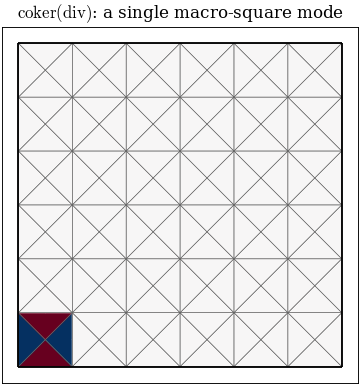

In [16]:
N = 6
mesh = crisscross_mesh(N)
C, _ = checkerboard_basis(mesh, N)
vec = C[:, 0].toarray().ravel()
markers = mesh.exterior_facets.unique_markers

f = Function(FunctionSpace(mesh, "DG", 0))
f.dat.data[:] = vec
lim = float(np.abs(vec).max())

fig, ax = plt.subplots(figsize=(4.4, 4.2))
tripcolor(f, axes=ax, cmap="RdBu_r", vmin=-lim, vmax=lim)
triplot(mesh, axes=ax, interior_kw={"linewidths": 0.35, "edgecolors": "0.4"},
        boundary_kw={"linewidths": 1.2, "colors": ["k"] * len(markers)})
ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
ax.set_title(r"$\mathrm{coker}(\operatorname{div})$: a single macro-square mode")
fig.savefig(FIGDIR / "topform_checkerboard_single.pdf")
plt.show()

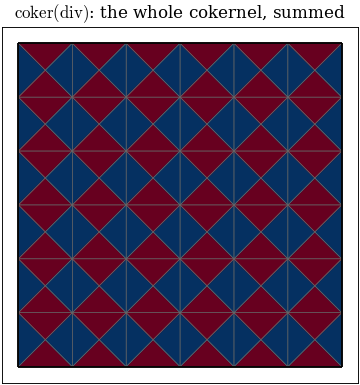

In [17]:
N = 6
mesh = crisscross_mesh(N)
C, _ = checkerboard_basis(mesh, N)
vec = C.sum(axis=1).A.ravel()
markers = mesh.exterior_facets.unique_markers

f = Function(FunctionSpace(mesh, "DG", 0))
f.dat.data[:] = vec
lim = float(np.abs(vec).max())

fig, ax = plt.subplots(figsize=(4.4, 4.2))
tripcolor(f, axes=ax, cmap="RdBu_r", vmin=-lim, vmax=lim)
triplot(mesh, axes=ax, interior_kw={"linewidths": 0.35, "edgecolors": "0.4"},
        boundary_kw={"linewidths": 1.2, "colors": ["k"] * len(markers)})
ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
ax.set_title(r"$\mathrm{coker}(\operatorname{div})$: the whole cokernel, summed")
fig.savefig(FIGDIR / "topform_checkerboard_all.pdf")
plt.show()

The construction is exact: $\operatorname{div}^{\mathsf T}C = 0$ to machine precision, $Z$ is
orthonormal and orthogonal to $C$, and $\operatorname{rank}(\operatorname{div}) = 3N^2$ at
every level. The cokernel really is the checkerboard, one mode per macro-square, and it
is the reason this element is only pathological on a criss-cross grid.

<a id="5"></a>
## 5. The eigensolver and the matching pipeline

Every formulation ends as a real pencil $Ax = \lambda Mx$ with $M$ singular — the
$\sigma$-block carries no mass, and in `A(CG)` the constrained boundary rows carry none
either. As in the $k=1$ tutorial the cure is a **reciprocal shift-and-invert** spectral
transformation: replace the pencil by $(A-\tau M)^{-1}M$, so that eigenvalues near $\tau$
converge first and the infinite ones converge last, and factorise the shifted matrix
with a direct solver because it is an indefinite saddle-point system.

The one difference from the $k=1$ case is the shift. Here the spectrum is real and
positive and starts at $\lambda_1 \ge 2\varepsilon$ (Section 1.3), so $\tau$ just below
$2\varepsilon$ puts the $N=100$ eigenvalues we want in the right order without any risk
of hitting the spectrum.

In [18]:
EPS_OPTS = {
    "eps_gen_non_hermitian": None,       # generalised, non-Hermitian pencil
    "eps_type": "krylovschur",
    "eps_target_magnitude": None,        # order by |lambda - tau|
    "eps_tol": 1e-11,
    "eps_max_it": 5000,
    "st_type": "sinvert",                # (A - tau M)^{-1} M
    "st_ksp_type": "preonly",            # the LU *is* the solve
    "st_pc_type": "lu",
    "st_pc_factor_mat_solver_type": "mumps",
    "st_mat_mumps_icntl_14": 800,        # working-space headroom for pivoting
}
_prefix = itertools.count()

#: registry consumed by `solve_topform`
FORMS = {
    "A(CG)":       dict(build=lambda mesh, N, **kw: primal_pencil(mesh, **kw),
                        shift=False, kind="primal"),
    "B(RT)":       dict(build=lambda mesh, N, **kw: mixed_pencil(mesh, "RT", **kw),
                        shift=False, kind="mixed"),
    "B(BDM)":      dict(build=lambda mesh, N, **kw: mixed_pencil(mesh, "BDM", **kw),
                        shift=False, kind="mixed"),
    "s(RT)":       dict(build=lambda mesh, N, **kw: mixed_pencil(mesh, "RT", **kw),
                        shift=True, kind="mixed"),
    "s(BDM)":      dict(build=lambda mesh, N, **kw: mixed_pencil(mesh, "BDM", **kw),
                        shift=True, kind="mixed"),
    "s(P1-divP1)": dict(build=lambda mesh, N, **kw: p1divp1_pencil(mesh, N, **kw),
                        shift=True, kind="restricted"),
}
FEEC_FORMS = ["A(CG)", "B(RT)", "B(BDM)", "s(RT)", "s(BDM)"]


@dataclass
class Spectrum:
    values: np.ndarray          # eigenvalues, shifted back, sorted by (Re, |Im|)
    space: object               # the FunctionSpace(s) the eigenvectors live in
    restriction: object         # Z for the restricted pencil, else None
    size: int                   # pencil dimension
    meta: dict
    eps_obj: object = None
    index: np.ndarray = None    # SLEPc indices matching `values`
    kappa: dict = None          # condition estimates for the matrix ST factorised

    @property
    def real(self):
        return self.values.real

    @property
    def kappa1(self):
        r"""Normwise $\kappa_1(A-\sigma M)$ of the solve that produced this spectrum."""
        return None if self.kappa is None else self.kappa[r"Hager $\kappa_1$"]


#: every condition estimate produced in this notebook, for the tally in Section 8
KAPPA_LOG = []


def solve_topform(form="B(RT)", wind="b0", N=32, degree=1, Rm=1.0, n_eigs=100,
                  nev=None, tau=None, mesh=None, L=L_DOMAIN, cond=True):
    r"""Solve the top-form eigenproblem for one (formulation, wind, $R_m$, mesh).

    `tau` defaults to $1.9\varepsilon$, just below $\lambda_1 \ge 2\varepsilon$.  The
    shifted formulations carry $\nu$ from Lemma 4 and hand back $\tilde\lambda-\nu$,
    so the returned eigenvalues are directly comparable across all six rows of
    `FORMS`.

    Unless `cond=False`, the condition of the matrix that was actually factorised,
    $A - \sigma M$ with $\sigma = \tau + \nu$, is estimated and attached to the
    result.  It is cheap next to the eigensolve, and computing it here rather than
    on request means no table in this notebook can quietly omit it.
    """
    mesh = crisscross_mesh(N, L) if mesh is None else mesh
    eps = Constant(1.0 / Rm)
    w = WINDS[wind]
    beta = w(mesh, L)

    spec = FORMS[form]
    nu = nu_min(w.sup, 1.0 / Rm) if spec["shift"] else 0.0
    A, M, space, Z = spec["build"](mesh, N, degree=degree, beta=beta, eps=eps, nu=nu)

    tau = (1.9 / Rm) if tau is None else tau
    nev = nev or min(n_eigs + 20, A.getSize()[0] - 1)

    opts = dict(EPS_OPTS, eps_target=tau + nu,
                eps_ncv=min(2 * nev + 30, A.getSize()[0]))
    prefix = f"tf{next(_prefix)}_"
    db = PETSc.Options()
    for k, v in opts.items():
        db[prefix + k] = v
    solver = SLEPc.EPS().create(comm=A.getComm())
    solver.setOptionsPrefix(prefix)
    solver.setOperators(A, M)
    solver.setDimensions(nev=nev)
    solver.setFromOptions()
    solver.solve()
    for k in opts:
        db.delValue(prefix + k)

    found = []
    for i in range(solver.getConverged()):
        z = complex(solver.getEigenvalue(i))
        if np.isfinite(z) and abs(z) < 1e10:
            found.append((i, z - nu))          # undo the Lemma 4 shift
    found = [p for p in found if abs(p[1]) > 1e-9]
    found.sort(key=lambda p: (p[1].real, abs(p[1].imag)))
    found = found[:n_eigs]

    kappa = condition_estimates(A, M, tau + nu) if cond else None
    if kappa is not None:
        KAPPA_LOG.append(dict(form=form, wind=wind, N=N, Rm=Rm, sigma=tau + nu,
                              **kappa))

    return Spectrum(np.array([z for _, z in found]), space, Z, A.getSize()[0],
                    dict(form=form, wind=wind, N=N, degree=degree, Rm=Rm,
                         eps=1.0 / Rm, tau=tau, nu=nu, kind=spec["kind"],
                         nconv=solver.getConverged(),
                         reason=solver.getConvergedReason()),
                    eps_obj=solver, index=np.array([i for i, _ in found]),
                    kappa=kappa)


def eigenfunction(spectrum, k):
    """The scalar field $u$ of the k-th eigenmode, as a Firedrake Function."""
    solver = spectrum.eps_obj
    A, _ = solver.getOperators()
    vr, vi = A.createVecRight(), A.createVecRight()
    solver.getEigenvector(int(spectrum.index[k]), vr, vi)
    arr = np.asarray(vr.getArray())
    kind, space = spectrum.meta["kind"], spectrum.space

    if kind == "restricted":                   # P1-divP1: lift V_h back to DG0
        S, Q = space
        f = Function(Q)
        f.dat.data[:] = spectrum.restriction @ arr[S.dim():]
        return f

    f = Function(space)                        # primal CG, or mixed RT/BDM x DG
    with f.dat.vec_wo as fv:
        fv.setArray(arr[:fv.getLocalSize()])
    return f.subfunctions[1] if kind == "mixed" else f

Two utilities do the bookkeeping for the rest of the notebook: the exact reference
spectra of Section 1.3, and a one-to-one **matching** routine. Detecting pollution by
"distance from the nearest exact eigenvalue" fails as soon as $\beta\neq 0$, where no
exact spectrum exists, and it also mistakes ordinary discretisation error for pollution
high in the spectrum. Matching a computed spectrum greedily against a *reference
computation on the same mesh* — a FEEC pair, which is guaranteed pollution-free by
Theorem 9 — leaves exactly the extra values behind.

In [19]:
def exact_spectrum(n, Rm=1.0, beta_sq=0.0, kmax=80):
    r"""$\varepsilon(m^2+n^2) + |\beta|^2/4\varepsilon$, $m,n\ge1$, with multiplicity."""
    eps = 1.0 / Rm
    vals = sorted(m * m + k * k for m in range(1, kmax) for k in range(1, kmax))
    return np.array(vals[:n], dtype=float) * eps + beta_sq / (4.0 * eps)


def match(test, reference, rtol=3e-3):
    """Greedy one-to-one matching of `test` against `reference`.

    Returns (matched, extra): `matched[i]` is the reference partner of `test[i]`
    (NaN where none), `extra` collects the test values left over.  Only the range
    covered by both is judged, so a shorter reference window cannot manufacture
    spurious values at the top end.
    """
    ref = list(reference)
    hi = max(abs(r) for r in ref) if ref else np.inf
    matched, extra = [], []
    for v in test:
        if abs(v) > hi:
            matched.append(np.nan); continue
        if not ref:
            extra.append(v); matched.append(np.nan); continue
        j = int(np.argmin([abs(r - v) for r in ref]))
        if abs(ref[j] - v) <= rtol * max(1.0, abs(v)):
            matched.append(ref.pop(j))
        else:
            extra.append(v); matched.append(np.nan)
    return np.array(matched), np.array(extra)

<a id="5.1"></a>
### 5.1 Is the shifted matrix well conditioned?

Shift-and-invert only works if $A - \sigma M$ can actually be inverted, and inverted
accurately. Both parts are at issue here: $M$ is singular, $A-\sigma M$ is an indefinite
saddle-point matrix, and $\sigma = \tau+\nu$ is a number we chose by hand. The condition
number $\kappa(A-\sigma M)$ is the quantity that settles it: it certifies that the
discrete saddle point is well posed — the discrete inf–sup constant of Lemma 4 is what
bounds it from below — and that the shift we are actually using is a good one.

Because it is the *operational* number that matters, `solve_topform` estimates it on
every call and attaches it to the result, and **every results table in this notebook
carries a $\kappa$ column**. Section 8 closes with the worst value seen anywhere.

Forming $\kappa_2$ exactly would mean a dense SVD, which is out of the question at these
sizes. Two sparse estimators are used instead, and cross-checked against each other:

* **MUMPS `COND1`** — the Arioli–Demmel–Duff error-analysis estimate, computed by the
  factorisation itself. `ICNTL(11) = 1` turns on full error analysis and the result lands
  in `RINFOG(10)`, which petsc4py exposes as `Mat.getMumpsRinfog(10)`. It is a
  *componentwise*, right-hand-side-dependent quantity, so it sits below the normwise
  condition number — it is the solver's own opinion of how accurately it just solved.
* **Hager–Higham $\kappa_1$** — $\|S\|_1\,\|S^{-1}\|_1$ with the second factor estimated by
  the same one-norm power iteration LAPACK's `gecon` uses, driven through a sparse LU.
  This is the ordinary *normwise* condition number.

Neither costs more than a fraction of the eigensolve. They are calibrated against exact
dense values on small meshes before being used anywhere.

In [20]:
def shifted_matrix(A, M, sigma):
    r"""$S = A - \sigma M$: exactly the matrix the ST hands to MUMPS."""
    S = A.copy()
    # A and M generally have different sparsity (the constrained rows of A(CG)
    # carry a diagonal that M does not), so the pattern must be declared unequal.
    S.axpy(-sigma, M, structure=PETSc.Mat.Structure.DIFFERENT_NONZERO_PATTERN)
    return S


def mumps_cond1(S, icntl14=800):
    """MUMPS' own condition estimate, RINFOG(10), via a throw-away LU + solve.

    `setFactorSetUpSolverType()` builds the factor Mat *before* the numeric
    factorisation, which is the only moment at which ICNTL(11) can still be set.
    The error analysis itself is performed during the solve, so a dummy solve is
    required to populate RINFOG.
    """
    ksp = PETSc.KSP().create(comm=S.getComm())
    ksp.setOperators(S)
    ksp.setType("preonly")
    pc = ksp.getPC()
    pc.setType("lu")
    pc.setFactorSolverType("mumps")
    pc.setFactorSetUpSolverType()
    F = pc.getFactorMatrix()
    F.setMumpsIcntl(11, 1)            # 1 = full error analysis -> RINFOG(10), (11)
    F.setMumpsIcntl(14, icntl14)
    ksp.setUp()
    b, x = S.createVecLeft(), S.createVecRight()
    b.set(1.0)
    ksp.solve(b, x)
    cond, infog1 = F.getMumpsRinfog(10), F.getMumpsInfog(1)
    ksp.destroy()
    return cond, infog1


def hager_cond1(S):
    r"""Normwise $\kappa_1 = \|S\|_1\|S^{-1}\|_1$, both factors by `onenormest`."""
    Ssp = to_scipy(S).tocsc()
    lu = spla.splu(Ssp)
    n = Ssp.shape[0]
    inverse = spla.LinearOperator(
        (n, n), matvec=lu.solve, rmatvec=lambda v: lu.solve(v, trans="T"))
    return spla.onenormest(Ssp) * spla.onenormest(inverse)


def condition_estimates(A, M, sigma, exact=False):
    """Both estimates for $A-\\sigma M$ (plus dense truth when `exact`)."""
    S = shifted_matrix(A, M, sigma)
    cond, infog1 = mumps_cond1(S)
    out = {"MUMPS COND1": cond, r"Hager $\kappa_1$": hager_cond1(S),
           "INFOG(1)": infog1}
    if exact:
        dense = to_scipy(S).toarray()
        out[r"exact $\kappa_2$"] = np.linalg.cond(dense, 2)
        out[r"exact $\kappa_1$"] = np.linalg.cond(dense, 1)
    return out


def condition_of(spectrum, exact=False):
    """Condition estimates for the matrix that *this* solve actually factorised."""
    A, M = spectrum.eps_obj.getOperators()
    return condition_estimates(A, M, spectrum.meta["tau"] + spectrum.meta["nu"],
                               exact=exact)

In [21]:
rows = []
for N in (4, 6, 8):
    for form in ("B(RT)", "s(P1-divP1)"):
        s = solve_topform(form=form, wind="b0", N=N, n_eigs=5)
        rows.append(dict(N=N, form=form, n=s.size, **condition_of(s, exact=True)))
df_cal = pd.DataFrame(rows).set_index(["N", "form"])
df_cal = df_cal[[r"exact $\kappa_2$", r"exact $\kappa_1$", r"Hager $\kappa_1$",
                 "MUMPS COND1", "n", "INFOG(1)"]]
fmt_table(df_cal, default="{:.3e}", rules=[("n", "{:.0f}"), ("INFOG", "{:.0f}")],
          caption=r"Calibration of the two sparse estimators against dense truth, "
                  r"$\beta=0$, $\sigma = 1.9$")

**Calibration of the two sparse estimators against dense truth, $\beta=0$, $\sigma = 1.9$**

exact $\kappa_2$ exact $\kappa_1$ Hager $\kappa_1$ MUMPS COND1  \
N form                                                                         
4 B(RT)              5.315e+02        1.284e+03        1.284e+03   3.023e+02   
  s(P1-divP1)        9.216e+01        4.773e+02        4.053e+02   9.236e+01   
6 B(RT)              7.687e+02        1.974e+03        1.974e+03   3.384e+02   
  s(P1-divP1)        1.542e+02        8.749e+02        7.504e+02   1.412e+02   
8 B(RT)              1.182e+03        3.006e+03        3.006e+03   4.073e+02   
  s(P1-divP1)        2.132e+02        1.247e+03        1.247e+03   1.842e+02   

                 n INFOG(1)  
N form                       
4 B(RT)        168        0  
  s(P1-divP1)  130        0  
6 B(RT)        372        0  
  s(P1-divP1)  278        0  
8 B(RT)        656        0  
  s(P1-divP1)  482        0

The Hager–Higham estimate reproduces the exact $\kappa_1$ to within a few per cent, which
is the expected behaviour of a one-norm estimator, and sits within a factor of three of
$\kappa_2$. MUMPS' `COND1` runs an order of magnitude lower, exactly as it should: it is a
componentwise quantity tied to one right-hand side, not a normwise bound. `INFOG(1) = 0`
throughout confirms the factorisations completed without error. Both track the same
trend, so either can be read as a diagnostic — the normwise $\kappa_1$ is quoted as *the*
condition number below, with `COND1` alongside as the solver's independent opinion.

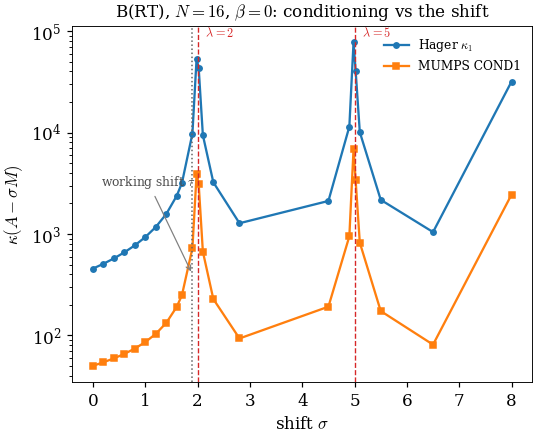

In [22]:
mesh_c = crisscross_mesh(16)
A_c, M_c, _, _ = mixed_pencil(mesh_c, "RT", 1)
sigmas = np.concatenate([np.linspace(0.0, 1.6, 9),
                         2.0 + np.array([-0.3, -0.1, -0.02, 0.02, 0.1, 0.3, 0.8]),
                         5.0 + np.array([-0.5, -0.1, -0.02, 0.02, 0.1, 0.5, 1.5, 3.0])])
sweep = [dict(sigma=sg, **{k: v for k, v in
                           condition_estimates(A_c, M_c, sg).items() if k != "INFOG(1)"})
         for sg in sigmas]
df_sweep = pd.DataFrame(sweep)

fig, ax = plt.subplots(figsize=(5.4, 4.2))
ax.semilogy(df_sweep["sigma"], df_sweep[r"Hager $\kappa_1$"], "o-", ms=3.5,
            color="C0", label=r"Hager $\kappa_1$")
ax.semilogy(df_sweep["sigma"], df_sweep["MUMPS COND1"], "s-", ms=3.5,
            color="C1", label="MUMPS COND1")
ax.axvline(2.0, color="C3", lw=0.9, ls="--")
ax.axvline(5.0, color="C3", lw=0.9, ls="--")
ax.text(2.0, ax.get_ylim()[1], r"  $\lambda=2$", color="C3", fontsize=8, va="top")
ax.text(5.0, ax.get_ylim()[1], r"  $\lambda=5$", color="C3", fontsize=8, va="top")
ax.axvline(1.9, color="0.4", lw=1.0, ls=":")
ax.annotate(r"working shift $\tau$", xy=(1.9, 4e2), xytext=(0.15, 3e3),
            fontsize=8, color="0.3",
            arrowprops=dict(arrowstyle="->", color="0.5", lw=0.8))
ax.set_xlabel(r"shift $\sigma$")
ax.set_ylabel(r"$\kappa(A-\sigma M)$")
ax.set_title(r"B(RT), $N=16$, $\beta=0$: conditioning vs the shift")
ax.legend(fontsize=8, frameon=False)
fig.savefig(FIGDIR / "topform_conditioning_shift.pdf")
plt.show()

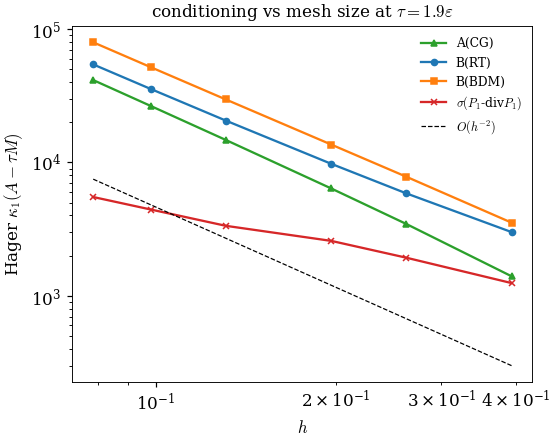

In [23]:
levels = (8, 12, 16, 24, 32, 40)
h_c = np.pi / np.array(levels, dtype=float)
k_acg = [condition_of(solve_topform(form="A(CG)", wind="b0", N=N, n_eigs=3))[r"Hager $\kappa_1$"] for N in levels]
k_rt = [condition_of(solve_topform(form="B(RT)", wind="b0", N=N, n_eigs=3))[r"Hager $\kappa_1$"] for N in levels]
k_bdm = [condition_of(solve_topform(form="B(BDM)", wind="b0", N=N, n_eigs=3))[r"Hager $\kappa_1$"] for N in levels]
k_p1 = [condition_of(solve_topform(form="s(P1-divP1)", wind="b0", N=N, n_eigs=3))[r"Hager $\kappa_1$"] for N in levels]

fig, ax = plt.subplots(figsize=(5.4, 4.2))
ax.loglog(h_c, k_acg, "^-", color="C2", ms=4, label="A(CG)")
ax.loglog(h_c, k_rt, "o-", color="C0", ms=4, label="B(RT)")
ax.loglog(h_c, k_bdm, "s-", color="C1", ms=4, label="B(BDM)")
ax.loglog(h_c, k_p1, "x-", color="C3", ms=4, label=r"$\sigma(P_1$-div$P_1)$")
ax.loglog(h_c, 3e2 * (h_c / h_c[0]) ** -2, "k--", lw=0.8, label=r"$O(h^{-2})$")
ax.set_xlabel(r"$h$")
ax.set_ylabel(r"Hager $\kappa_1(A-\tau M)$")
ax.set_title(r"conditioning vs mesh size at $\tau = 1.9\varepsilon$")
ax.legend(fontsize=8, frameon=False)
fig.savefig(FIGDIR / "topform_conditioning_mesh.pdf")
plt.show()

The left panel locates the working shift. $\tau = 1.9\varepsilon$ gives
$\kappa_1 \approx 10^4$, roughly an order of magnitude above the best available anywhere on
the axis and four orders below where the estimate has gone by the time $\sigma$ is within
$10^{-3}$ of $\lambda_1$. So the shift is a genuinely comfortable choice, not a lucky one:
it buys the amplification that makes shift-and-invert converge on the modes we want while
leaving the factorisation with about twelve of sixteen digits intact. (That $\kappa$
diverges as $\sigma\to\lambda_j$ is inevitable — $A-\sigma M$ is singular there — and is
not the point; the point is the margin at the shift we use.)

The right panel is the scaling that governs every run below: the expected $O(h^{-2})$ of a
second-order elliptic operator, in all four discretisations. At the finest mesh used
anywhere here, $\kappa_1$ is still under $10^5$.

One warning while the numbers are in view. `s(P1-divP1)` is the **best**-conditioned of
the four, because its $V_h$ is the smallest — and it is the one that pollutes. A
well-conditioned shifted matrix certifies that the linear algebra is trustworthy. It says
nothing whatever about whether the eigenvalues mean anything.

<a id="6"></a>
## 6. Experiment I — the diffusive limit $\beta = 0$

With no wind the operator is $-\varepsilon\Delta$ with Dirichlet data and the answer is
known exactly. Any discrepancy is discretisation error or pollution, and the two are
easy to tell apart: discretisation error shrinks with $h$, pollution does not.

In [24]:
N_BASE, N_EIGS = 32, 100
mesh = crisscross_mesh(N_BASE)
ALL_FORMS = list(FORMS)

runs0 = {f: solve_topform(form=f, wind="b0", N=N_BASE, mesh=mesh, n_eigs=N_EIGS)
         for f in ALL_FORMS}

diag = pd.DataFrame([
    dict(formulation=f, pencil=s.size, nu=s.meta["nu"],
         sigma=s.meta["tau"] + s.meta["nu"], converged=s.meta["nconv"],
         reason=s.meta["reason"], **{r"$\lambda_{\max}$": s.real.max()},
         **{k: v for k, v in s.kappa.items() if k != "INFOG(1)"})
    for f, s in runs0.items()]).set_index("formulation")
fmt_table(diag, default="{:.3e}",
          rules=[("pencil", "{:.0f}"), ("converged", "{:.0f}"), ("reason", "{:.0f}"),
                 ("nu", "{:.1f}"), ("sigma", "{:.2f}"), ("lambda", "{:.2f}")],
          caption=rf"Solver diagnostics at $N={N_BASE}$, $\beta=0$. $\sigma=\tau+\nu$ is "
                  r"the shift actually handed to MUMPS; `reason` $=1$ is SLEPc's "
                  r"converged flag.")

**Solver diagnostics at $N=32$, $\beta=0$. $\sigma=\tau+\nu$ is the shift actually handed to MUMPS; `reason` $=1$ is SLEPc's converged flag.**

,pencil,nu,sigma,converged,reason,$\lambda_{\max}$,MUMPS COND1,Hager $\kappa_1$
formulation,,,,,,,,
A(CG),2113,0.0,1.90,152,1,152.31,1.649e+04,2.641e+04
B(RT),10304,0.0,1.90,144,1,142.22,1.383e+03,3.542e+04
B(BDM),16512,0.0,1.90,147,1,150.57,1.364e+03,5.159e+04
s(RT),10304,2.0,3.90,144,1,142.22,1.383e+03,3.542e+04
s(BDM),16512,2.0,3.90,147,1,150.57,1.364e+03,5.159e+04
s(P1-divP1),7298,2.0,3.90,135,1,112.14,6.092e+02,5.068e+03


Every solve converged (`reason = 1`), and every shifted matrix is comfortably invertible:
the largest $\kappa_1$ over the six discretisations is $\sim\!5\times10^4$, so the LU
factorisation loses about five of the sixteen available digits — irrelevant beside an
$O(h^2)$ discretisation error of $10^{-3}$. Whatever goes wrong below is not linear
algebra.

In [25]:
ex10 = exact_spectrum(10)
tbl = pd.DataFrame({"exact": ex10} |
                   {f: runs0[f].real[:10] for f in ALL_FORMS},
                   index=[f"$\\lambda_{{{i+1}}}$" for i in range(10)])
# every results table in this notebook closes with the conditioning of the matrix
# that produced it
tbl.loc[r"$\kappa_1(A-\sigma M)$"] = [np.nan] + [runs0[f].kappa1 for f in ALL_FORMS]
fmt_table(tbl, row_rules=[(r"\kappa_1", "{:.2e}")],
          caption=r"First ten eigenvalues, $\beta = 0$, $R_m = 1$, "
                       rf"criss-cross $N = {N_BASE}$, lowest order")

**First ten eigenvalues, $\beta = 0$, $R_m = 1$, criss-cross $N = 32$, lowest order**

,exact,A(CG),B(RT),B(BDM),s(RT),s(BDM),s(P1-divP1)
$\lambda_{1}$,2.000000,2.001339,1.999464,2.001071,1.999464,2.001071,2.001071
$\lambda_{2}$,5.000000,5.010183,4.998459,5.006693,4.998459,5.006693,5.006691
$\lambda_{3}$,5.000000,5.010183,4.998459,5.006693,4.998459,5.006693,5.006691
$\lambda_{4}$,8.000000,8.021456,7.991429,8.017138,7.991429,8.017138,5.995182
$\lambda_{5}$,10.000000,10.046394,9.999444,10.026765,9.999444,10.026765,8.017131
$\lambda_{6}$,10.000000,10.046394,9.999444,10.026765,9.999444,10.026765,10.026751
$\lambda_{7}$,13.000000,13.061740,12.982374,13.045252,12.982374,13.045252,10.026751
$\lambda_{8}$,13.000000,13.061740,12.982374,13.045252,12.982374,13.045252,13.045221
$\lambda_{9}$,17.000000,17.142272,17.006374,17.077320,17.006374,17.077320,13.045221
$\lambda_{10}$,17.000000,17.142272,17.006374,17.077320,17.006374,17.077320,14.927200


Read row by row. The five FEEC rows track `exact` down the column; `s(P1-divP1)` agrees
with them for $\lambda_1,\lambda_2,\lambda_3$ and then **inserts a value near 6 that
nobody else has**, pushing every subsequent entry one place down. Six is not of the form
$m^2+n^2$ with $m,n\ge1$ — the exact spectrum jumps straight from $5$ to $8$ — so this is
not a badly approximated eigenvalue. It is an eigenvalue of nothing.

Note also that `B(RT)` and `s(RT)` agree to every printed digit, as do `B(BDM)` and
`s(BDM)`. The shift $\nu$ of Lemma 3 buys well-posedness of the source problem and
changes the spectrum not at all:

In [26]:
for a, b in [("B(RT)", "s(RT)"), ("B(BDM)", "s(BDM)")]:
    d = np.abs(runs0[a].values[:60] - runs0[b].values[:60]).max()
    print(f"  max |{a} - {b}| over the first 60 eigenvalues:  {d:.3e}"
          f"   (nu = {runs0[b].meta['nu']:.1f})")

  max |B(RT) - s(RT)| over the first 60 eigenvalues:  0.000e+00   (nu = 2.0)
  max |B(BDM) - s(BDM)| over the first 60 eigenvalues:  2.136e-12   (nu = 2.0)


In [27]:
ex = exact_spectrum(N_EIGS + 40)
STYLE = {"A(CG)": ("C2", "^"), "B(RT)": ("C0", "o"), "B(BDM)": ("C1", "s"),
         "s(RT)": ("C0", "o"), "s(BDM)": ("C1", "s"), "s(P1-divP1)": ("C3", "x")}
show = ["A(CG)", "B(RT)", "B(BDM)", "s(P1-divP1)"]
idx = np.arange(1, N_EIGS + 1)

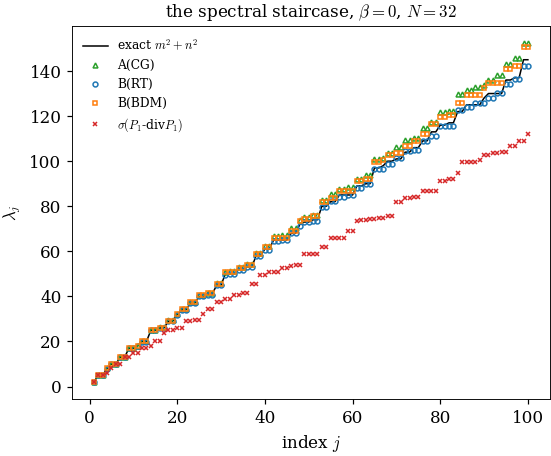

In [28]:
fig, ax = plt.subplots(figsize=(5.6, 4.4))
ax.plot(idx, ex[:N_EIGS], "k-", lw=1.0, label=r"exact $m^2+n^2$")
ax.plot(idx, runs0["A(CG)"].real[:N_EIGS], "^", ms=3.2, color="C2", mfc="none", label="A(CG)")
ax.plot(idx, runs0["B(RT)"].real[:N_EIGS], "o", ms=3.2, color="C0", mfc="none", label="B(RT)")
ax.plot(idx, runs0["B(BDM)"].real[:N_EIGS], "s", ms=3.2, color="C1", mfc="none", label="B(BDM)")
ax.plot(idx, runs0["s(P1-divP1)"].real[:N_EIGS], "x", ms=3.2, color="C3", label=r"$\sigma(P_1$-div$P_1)$")
ax.set_xlabel(r"index $j$")
ax.set_ylabel(r"$\lambda_j$")
ax.set_title(rf"the spectral staircase, $\beta=0$, $N={N_BASE}$")
ax.legend(fontsize=8, frameon=False)
fig.savefig(FIGDIR / "topform_staircase.pdf")
plt.show()

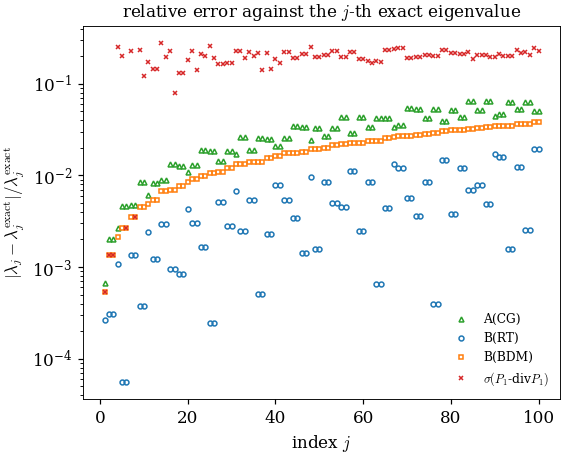

In [29]:
fig, ax = plt.subplots(figsize=(5.6, 4.4))
ax.semilogy(idx, np.abs(runs0["A(CG)"].real[:N_EIGS] - ex[:N_EIGS]) / ex[:N_EIGS],
            "^", ms=3.2, color="C2", mfc="none", label="A(CG)")
ax.semilogy(idx, np.abs(runs0["B(RT)"].real[:N_EIGS] - ex[:N_EIGS]) / ex[:N_EIGS],
            "o", ms=3.2, color="C0", mfc="none", label="B(RT)")
ax.semilogy(idx, np.abs(runs0["B(BDM)"].real[:N_EIGS] - ex[:N_EIGS]) / ex[:N_EIGS],
            "s", ms=3.2, color="C1", mfc="none", label="B(BDM)")
ax.semilogy(idx, np.abs(runs0["s(P1-divP1)"].real[:N_EIGS] - ex[:N_EIGS]) / ex[:N_EIGS],
            "x", ms=3.2, color="C3", label=r"$\sigma(P_1$-div$P_1)$")
ax.set_xlabel(r"index $j$")
ax.set_ylabel(r"$|\lambda_j - \lambda_j^{\rm exact}|/\lambda_j^{\rm exact}$")
ax.set_title(r"relative error against the $j$-th exact eigenvalue")
ax.legend(fontsize=8, frameon=False)
fig.savefig(FIGDIR / "topform_staircase_error.pdf")
plt.show()

The right-hand panel is the cleanest statement of the problem. The FEEC rows sit on a
smooth error curve rising like $j\,h^2$, which is ordinary discretisation error. The
`s(P1-divP1)` curve tracks them for the first three indices and then **jumps by two
orders of magnitude and never recovers**: once a spurious value has been inserted, every
subsequent index is compared against the wrong exact eigenvalue. A single extra mode
corrupts the entire tail of the spectrum.

### 6.1 Convergence of the genuine spectrum

Before asking what the extra eigenvalues do, it is worth confirming that the ones that
*should* be there behave. The first five eigenvalues are tracked together under
$h$-refinement, and so are the corresponding eigen**functions**.

Two details make this study a little different from the usual one.

* **Eigenvalues are matched by value, not by position.** `s(P1-divP1)` inserts a spurious
  value at $\lambda\approx6$, so its fourth computed eigenvalue is not its approximation to
  $\lambda_4 = 8$. A greedy one-to-one assignment against the exact list repairs the
  indexing; without it the polluting element would appear to diverge when in fact its
  genuine modes are perfectly well behaved.
* **Eigenfunctions are compared by eigenspace.** $\lambda = 5$ and $\lambda = 10$ are
  double, and on a degenerate eigenspace a computed eigenvector is defined only up to a
  rotation within the space. The error reported is the sine of the largest principal angle
  between the computed and exact eigenspaces in $L^2$ — the gap between subspaces, which
  reduces to the ordinary normalised error when the eigenvalue is simple.

In [30]:
DX_HI = dx(metadata={"quadrature_degree": 10})
N_TRACK = 5           # eigenvalues followed individually

#: Exact eigenvalue clusters of the Dirichlet Laplacian on (0,pi)^2 covering the
#: first five eigenvalues, with the index pairs whose sin(mx)sin(ny) span each
#: eigenspace.  The lambda = 10 pair is carried whole rather than cut in half.
CLUSTERS = [(2.0, [(1, 1)]),
            (5.0, [(1, 2), (2, 1)]),
            (8.0, [(2, 2)]),
            (10.0, [(1, 3), (3, 1)])]


def exact_mode(mesh, m, n):
    """The Dirichlet eigenfunction u_mn = sin(mx) sin(ny)."""
    x, y = SpatialCoordinate(mesh)
    return sin(m * x) * sin(n * y)


def rates(h, e):
    """Observed order between consecutive refinement levels."""
    h, e = np.asarray(h, float), np.asarray(e, float)
    r = np.full(e.shape, np.nan)
    with np.errstate(divide="ignore", invalid="ignore"):
        r[1:] = np.log(e[:-1] / e[1:]) / np.log(h[:-1] / h[1:])
    return r


def assign(exact, computed):
    """Greedy one-to-one: the computed value nearest each exact eigenvalue.

    Needed because `s(P1-divP1)` interleaves spurious values with the genuine
    ones, so the j-th computed eigenvalue is not the approximation to the j-th
    exact one.
    """
    pool = list(computed)
    out = []
    for value in exact:
        j = int(np.argmin([abs(c - value) for c in pool]))
        out.append(pool.pop(j))
    return np.array(out)


def _whiten(G):
    """W with W^T G W = I, dropping numerically null directions.

    An eigendecomposition rather than a Cholesky: on coarse meshes the computed
    basis of a cluster can be close to rank deficient, where a Cholesky fails.
    """
    w, V = np.linalg.eigh(G)
    keep = w > w.max() * 1e-13
    return V[:, keep] / np.sqrt(w[keep])


def subspace_error(computed, exact):
    """Sine of the largest principal angle between two L2 subspaces (the gap).

    With orthonormalised bases the singular values of the cross-Gram matrix are
    the cosines of the principal angles, so the largest angle is set by the
    smallest singular value.
    """
    gram = lambda P, Q: np.array([[assemble(inner(a, b) * DX_HI) for b in Q]
                                  for a in P])
    Wc, We = _whiten(gram(computed, computed)), _whiten(gram(exact, exact))
    sv = np.linalg.svd(Wc.T @ gram(computed, exact) @ We, compute_uv=False)
    return float(np.sqrt(max(0.0, 1.0 - min(sv.min(), 1.0) ** 2)))


def convergence_study(form, levels, degree=1):
    """Eigenvalue errors for the first N_TRACK modes, and the eigenspace gaps."""
    exact = exact_spectrum(N_TRACK)
    rows_e, rows_f = [], []
    for N in levels:
        mesh = crisscross_mesh(N)
        res = solve_topform(form=form, wind="b0", N=N, mesh=mesh, degree=degree,
                            n_eigs=25, nev=40)
        lam = res.real
        got = assign(exact, lam)
        rows_e.append(dict(N=N, h=np.pi / N, dof=res.size,
                           **{f"$\\lambda_{{{j+1}}}$": abs(got[j] - exact[j]) / exact[j]
                              for j in range(N_TRACK)},
                           **{r"$\kappa_1$": res.kappa1}))

        row = dict(N=N, h=np.pi / N)
        for value, modes in CLUSTERS:
            idx = np.argsort(np.abs(lam - value))[:len(modes)]
            row[f"$\\lambda={value:g}$"] = subspace_error(
                [eigenfunction(res, int(i)) for i in idx],
                [exact_mode(mesh, m, n) for m, n in modes])
        row[r"$\kappa_1$"] = res.kappa1
        rows_f.append(row)
    return (pd.DataFrame(rows_e).set_index("N"),
            pd.DataFrame(rows_f).set_index("N"))


CONV_LEVELS = (4, 8, 16, 24, 32)
CONV_FORMS = ["A(CG)", "B(RT)", "B(BDM)", "s(P1-divP1)"]
conv_eig, conv_fun = {}, {}
for f in CONV_FORMS:
    conv_eig[f], conv_fun[f] = convergence_study(f, CONV_LEVELS)

In [31]:
def rate_frame(df, cols):
    """Interleave each error column with its observed rate."""
    out = pd.DataFrame(index=df.index)
    out["h"] = df["h"]
    for c in cols:
        out[c] = df[c]
        out[f"rate {c}"] = rates(df["h"], df[c])
    out[r"$\kappa_1$"] = df[r"$\kappa_1$"]
    return out


EIG_COLS = [f"$\\lambda_{{{j+1}}}$" for j in range(N_TRACK)]
FUN_COLS = [f"$\\lambda={v:g}$" for v, _ in CLUSTERS]

for f in CONV_FORMS:
    display(fmt_table(
        rate_frame(conv_eig[f], EIG_COLS), default="{:.3e}",
        rules=[("rate", "{:.2f}"), ("h", "{:.5f}"), (r"$\kappa_1$", "{:.2e}")],
        caption=f"$h$-refinement, **{f}**, $\\beta=0$: relative error in the first "
                f"{N_TRACK} genuine eigenvalues (expected $O(h^2)$)"))

**$h$-refinement, **A(CG)**, $\beta=0$: relative error in the first 5 genuine eigenvalues (expected $O(h^2)$)**

,h,$\lambda_{1}$,rate $\lambda_{1}$,$\lambda_{2}$,rate $\lambda_{2}$,$\lambda_{3}$,rate $\lambda_{3}$,$\lambda_{4}$,rate $\lambda_{4}$,$\lambda_{5}$,rate $\lambda_{5}$,$\kappa_1$
N,,,,,,,,,,,,
4,0.78540,4.401e-02,--,1.362e-01,--,1.362e-01,--,1.870e-01,--,2.969e-01,--,2.41e+02
8,0.39270,1.078e-02,2.03,3.302e-02,2.04,3.302e-02,2.04,4.401e-02,2.09,7.578e-02,1.97,1.40e+03
16,0.19635,2.682e-03,2.01,8.169e-03,2.02,8.169e-03,2.02,1.078e-02,2.03,1.865e-02,2.02,6.38e+03
24,0.13090,1.191e-03,2.00,3.623e-03,2.00,3.623e-03,2.00,4.774e-03,2.01,8.258e-03,2.01,1.47e+04
32,0.09817,6.696e-04,2.00,2.037e-03,2.00,2.037e-03,2.00,2.682e-03,2.00,4.639e-03,2.00,2.64e+04


**$h$-refinement, **B(RT)**, $\beta=0$: relative error in the first 5 genuine eigenvalues (expected $O(h^2)$)**

,h,$\lambda_{1}$,rate $\lambda_{1}$,$\lambda_{2}$,rate $\lambda_{2}$,$\lambda_{3}$,rate $\lambda_{3}$,$\lambda_{4}$,rate $\lambda_{4}$,$\lambda_{5}$,rate $\lambda_{5}$,$\kappa_1$
N,,,,,,,,,,,,
4,0.78540,1.726e-02,--,2.142e-02,--,2.142e-02,--,7.117e-02,--,1.502e-02,--,1.28e+03
8,0.39270,4.291e-03,2.01,5.024e-03,2.09,5.024e-03,2.09,1.726e-02,2.04,1.421e-03,3.40,3.01e+03
16,0.19635,1.071e-03,2.00,1.238e-03,2.02,1.238e-03,2.02,4.291e-03,2.01,2.481e-04,2.52,9.76e+03
24,0.13090,4.761e-04,2.00,5.485e-04,2.01,5.485e-04,2.01,1.905e-03,2.00,1.018e-04,2.20,2.06e+04
32,0.09817,2.678e-04,2.00,3.083e-04,2.00,3.083e-04,2.00,1.071e-03,2.00,5.565e-05,2.10,3.54e+04


**$h$-refinement, **B(BDM)**, $\beta=0$: relative error in the first 5 genuine eigenvalues (expected $O(h^2)$)**

,h,$\lambda_{1}$,rate $\lambda_{1}$,$\lambda_{2}$,rate $\lambda_{2}$,$\lambda_{3}$,rate $\lambda_{3}$,$\lambda_{4}$,rate $\lambda_{4}$,$\lambda_{5}$,rate $\lambda_{5}$,$\kappa_1$
N,,,,,,,,,,,,
4,0.78540,3.430e-02,--,8.444e-02,--,8.444e-02,--,1.333e-01,--,1.590e-01,--,8.01e+02
8,0.39270,8.573e-03,2.00,2.139e-02,1.98,2.139e-02,1.98,3.430e-02,1.96,4.253e-02,1.90,3.54e+03
16,0.19635,2.142e-03,2.00,5.354e-03,2.00,5.354e-03,2.00,8.573e-03,2.00,1.070e-02,1.99,1.36e+04
24,0.13090,9.520e-04,2.00,2.380e-03,2.00,2.380e-03,2.00,3.809e-03,2.00,4.757e-03,2.00,2.96e+04
32,0.09817,5.355e-04,2.00,1.339e-03,2.00,1.339e-03,2.00,2.142e-03,2.00,2.677e-03,2.00,5.16e+04


**$h$-refinement, **s(P1-divP1)**, $\beta=0$: relative error in the first 5 genuine eigenvalues (expected $O(h^2)$)**

,h,$\lambda_{1}$,rate $\lambda_{1}$,$\lambda_{2}$,rate $\lambda_{2}$,$\lambda_{3}$,rate $\lambda_{3}$,$\lambda_{4}$,rate $\lambda_{4}$,$\lambda_{5}$,rate $\lambda_{5}$,$\kappa_1$
N,,,,,,,,,,,,
4,0.78540,3.397e-02,--,8.060e-02,--,8.060e-02,--,1.254e-01,--,1.392e-01,--,4.05e+02
8,0.39270,8.557e-03,1.99,2.127e-02,1.92,2.127e-02,1.92,3.394e-02,1.89,4.196e-02,1.73,1.08e+03
16,0.19635,2.141e-03,2.00,5.348e-03,1.99,5.348e-03,1.99,8.557e-03,1.99,1.067e-02,1.98,2.58e+03
24,0.13090,9.518e-04,2.00,2.379e-03,2.00,2.379e-03,2.00,3.806e-03,2.00,4.753e-03,1.99,3.35e+03
32,0.09817,5.354e-04,2.00,1.338e-03,2.00,1.338e-03,2.00,2.141e-03,2.00,2.675e-03,2.00,5.07e+03


In [32]:
for f in CONV_FORMS:
    display(fmt_table(
        rate_frame(conv_fun[f], FUN_COLS), default="{:.3e}",
        rules=[("rate", "{:.2f}"), ("h", "{:.5f}"), (r"$\kappa_1$", "{:.2e}")],
        caption=f"Eigenfunction convergence, **{f}**, $\\beta=0$: gap between the "
                r"computed and exact eigenspaces of $u$"))

**Eigenfunction convergence, **A(CG)**, $\beta=0$: gap between the computed and exact eigenspaces of $u$**

,h,$\lambda=2$,rate $\lambda=2$,$\lambda=5$,rate $\lambda=5$,$\lambda=8$,rate $\lambda=8$,$\lambda=10$,rate $\lambda=10$,$\kappa_1$
N,,,,,,,,,,
4,0.78540,2.407e-02,--,8.349e-02,--,1.183e-01,--,1.000e+00,--,2.41e+02
8,0.39270,5.692e-03,2.08,1.832e-02,2.19,2.407e-02,2.30,4.334e-02,4.53,1.40e+03
16,0.19635,1.403e-03,2.02,4.427e-03,2.05,5.692e-03,2.08,1.014e-02,2.10,6.38e+03
24,0.13090,6.219e-04,2.01,1.955e-03,2.02,2.503e-03,2.03,4.451e-03,2.03,1.47e+04
32,0.09817,3.495e-04,2.00,1.097e-03,2.01,1.403e-03,2.01,2.493e-03,2.02,2.64e+04


**Eigenfunction convergence, **B(RT)**, $\beta=0$: gap between the computed and exact eigenspaces of $u$**

,h,$\lambda=2$,rate $\lambda=2$,$\lambda=5$,rate $\lambda=5$,$\lambda=8$,rate $\lambda=8$,$\lambda=10$,rate $\lambda=10$,$\kappa_1$
N,,,,,,,,,,
4,0.78540,1.837e-01,--,2.870e-01,--,3.605e-01,--,4.005e-01,--,1.28e+03
8,0.39270,9.238e-02,0.99,1.456e-01,0.98,1.837e-01,0.97,2.047e-01,0.97,3.01e+03
16,0.19635,4.626e-02,1.00,7.308e-02,0.99,9.238e-02,0.99,1.032e-01,0.99,9.76e+03
24,0.13090,3.085e-02,1.00,4.876e-02,1.00,6.165e-02,1.00,6.890e-02,1.00,2.06e+04
32,0.09817,2.314e-02,1.00,3.658e-02,1.00,4.626e-02,1.00,5.171e-02,1.00,3.54e+04


**Eigenfunction convergence, **B(BDM)**, $\beta=0$: gap between the computed and exact eigenspaces of $u$**

,h,$\lambda=2$,rate $\lambda=2$,$\lambda=5$,rate $\lambda=5$,$\lambda=8$,rate $\lambda=8$,$\lambda=10$,rate $\lambda=10$,$\kappa_1$
N,,,,,,,,,,
4,0.78540,1.837e-01,--,2.867e-01,--,3.594e-01,--,1.000e+00,--,8.01e+02
8,0.39270,9.238e-02,0.99,1.456e-01,0.98,1.837e-01,0.97,2.047e-01,2.29,3.54e+03
16,0.19635,4.626e-02,1.00,7.308e-02,0.99,9.238e-02,0.99,1.032e-01,0.99,1.36e+04
24,0.13090,3.085e-02,1.00,4.875e-02,1.00,6.165e-02,1.00,6.890e-02,1.00,2.96e+04
32,0.09817,2.314e-02,1.00,3.658e-02,1.00,4.626e-02,1.00,5.171e-02,1.00,5.16e+04


**Eigenfunction convergence, **s(P1-divP1)**, $\beta=0$: gap between the computed and exact eigenspaces of $u$**

,h,$\lambda=2$,rate $\lambda=2$,$\lambda=5$,rate $\lambda=5$,$\lambda=8$,rate $\lambda=8$,$\lambda=10$,rate $\lambda=10$,$\kappa_1$
N,,,,,,,,,,
4,0.78540,1.838e-01,--,2.906e-01,--,3.824e-01,--,1.000e+00,--,4.05e+02
8,0.39270,9.238e-02,0.99,1.459e-01,0.99,1.838e-01,1.06,2.063e-01,2.28,1.08e+03
16,0.19635,4.626e-02,1.00,7.312e-02,1.00,9.238e-02,0.99,1.034e-01,1.00,2.58e+03
24,0.13090,3.085e-02,1.00,4.877e-02,1.00,6.165e-02,1.00,6.896e-02,1.00,3.35e+03
32,0.09817,2.314e-02,1.00,3.658e-02,1.00,4.626e-02,1.00,5.173e-02,1.00,5.07e+03


In [33]:
EIG_COLOURS = ["C0", "C1", "C2", "C3", "C4"]
FUN_COLOURS = ["C0", "C3", "C1", "C2"]

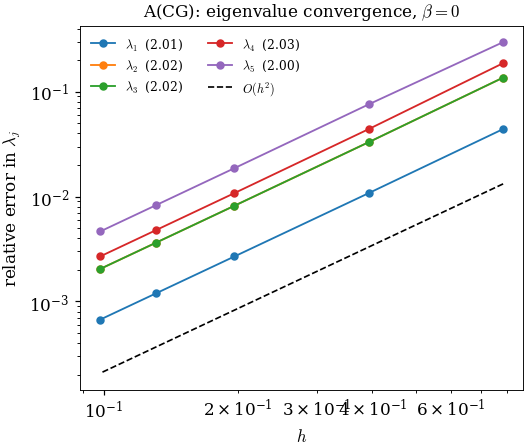

In [34]:
df = conv_eig["A(CG)"]
h = df["h"].to_numpy()
e1 = df[EIG_COLS[0]].to_numpy()
e2 = df[EIG_COLS[1]].to_numpy()
e3 = df[EIG_COLS[2]].to_numpy()
e4 = df[EIG_COLS[3]].to_numpy()
e5 = df[EIG_COLS[4]].to_numpy()

fig, ax = plt.subplots(figsize=(5.2, 4.3))
ax.loglog(h, e1, "o-", color=EIG_COLOURS[0], ms=4.5, lw=1.2,
          label=rf"$\lambda_{1}$  ({np.nanmean(rates(h, e1)[1:]):.2f})")
ax.loglog(h, e2, "o-", color=EIG_COLOURS[1], ms=4.5, lw=1.2,
          label=rf"$\lambda_{2}$  ({np.nanmean(rates(h, e2)[1:]):.2f})")
ax.loglog(h, e3, "o-", color=EIG_COLOURS[2], ms=4.5, lw=1.2,
          label=rf"$\lambda_{3}$  ({np.nanmean(rates(h, e3)[1:]):.2f})")
ax.loglog(h, e4, "o-", color=EIG_COLOURS[3], ms=4.5, lw=1.2,
          label=rf"$\lambda_{4}$  ({np.nanmean(rates(h, e4)[1:]):.2f})")
ax.loglog(h, e5, "o-", color=EIG_COLOURS[4], ms=4.5, lw=1.2,
          label=rf"$\lambda_{5}$  ({np.nanmean(rates(h, e5)[1:]):.2f})")

# Reference slope, anchored a factor 0.30 below the lowest curve.
ref = 0.30 * min(e1[0], e2[0], e3[0], e4[0], e5[0])
ax.loglog(h, ref * (h / h[0]) ** 2, "k--", lw=1.1, label=r"$O(h^2)$")

ax.set_xlabel(r"$h$")
ax.set_ylabel(r"relative error in $\lambda_j$")
ax.set_title(r"A(CG): eigenvalue convergence, $\beta = 0$")
ax.legend(fontsize=8, frameon=False, ncol=2)
fig.savefig(FIGDIR / "topform_conv_eig_A_CG.pdf")
plt.show()

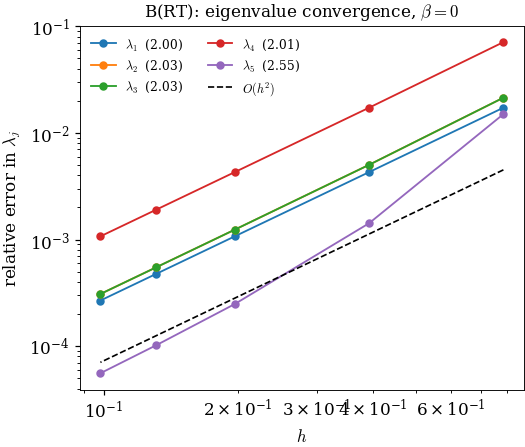

In [35]:
df = conv_eig["B(RT)"]
h = df["h"].to_numpy()
e1 = df[EIG_COLS[0]].to_numpy()
e2 = df[EIG_COLS[1]].to_numpy()
e3 = df[EIG_COLS[2]].to_numpy()
e4 = df[EIG_COLS[3]].to_numpy()
e5 = df[EIG_COLS[4]].to_numpy()

fig, ax = plt.subplots(figsize=(5.2, 4.3))
ax.loglog(h, e1, "o-", color=EIG_COLOURS[0], ms=4.5, lw=1.2,
          label=rf"$\lambda_{1}$  ({np.nanmean(rates(h, e1)[1:]):.2f})")
ax.loglog(h, e2, "o-", color=EIG_COLOURS[1], ms=4.5, lw=1.2,
          label=rf"$\lambda_{2}$  ({np.nanmean(rates(h, e2)[1:]):.2f})")
ax.loglog(h, e3, "o-", color=EIG_COLOURS[2], ms=4.5, lw=1.2,
          label=rf"$\lambda_{3}$  ({np.nanmean(rates(h, e3)[1:]):.2f})")
ax.loglog(h, e4, "o-", color=EIG_COLOURS[3], ms=4.5, lw=1.2,
          label=rf"$\lambda_{4}$  ({np.nanmean(rates(h, e4)[1:]):.2f})")
ax.loglog(h, e5, "o-", color=EIG_COLOURS[4], ms=4.5, lw=1.2,
          label=rf"$\lambda_{5}$  ({np.nanmean(rates(h, e5)[1:]):.2f})")

# Reference slope, anchored a factor 0.30 below the lowest curve.
ref = 0.30 * min(e1[0], e2[0], e3[0], e4[0], e5[0])
ax.loglog(h, ref * (h / h[0]) ** 2, "k--", lw=1.1, label=r"$O(h^2)$")

ax.set_xlabel(r"$h$")
ax.set_ylabel(r"relative error in $\lambda_j$")
ax.set_title(r"B(RT): eigenvalue convergence, $\beta = 0$")
ax.legend(fontsize=8, frameon=False, ncol=2)
fig.savefig(FIGDIR / "topform_conv_eig_B_RT.pdf")
plt.show()

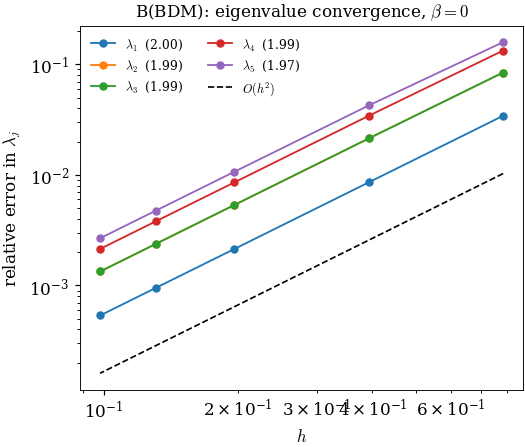

In [36]:
df = conv_eig["B(BDM)"]
h = df["h"].to_numpy()
e1 = df[EIG_COLS[0]].to_numpy()
e2 = df[EIG_COLS[1]].to_numpy()
e3 = df[EIG_COLS[2]].to_numpy()
e4 = df[EIG_COLS[3]].to_numpy()
e5 = df[EIG_COLS[4]].to_numpy()

fig, ax = plt.subplots(figsize=(5.2, 4.3))
ax.loglog(h, e1, "o-", color=EIG_COLOURS[0], ms=4.5, lw=1.2,
          label=rf"$\lambda_{1}$  ({np.nanmean(rates(h, e1)[1:]):.2f})")
ax.loglog(h, e2, "o-", color=EIG_COLOURS[1], ms=4.5, lw=1.2,
          label=rf"$\lambda_{2}$  ({np.nanmean(rates(h, e2)[1:]):.2f})")
ax.loglog(h, e3, "o-", color=EIG_COLOURS[2], ms=4.5, lw=1.2,
          label=rf"$\lambda_{3}$  ({np.nanmean(rates(h, e3)[1:]):.2f})")
ax.loglog(h, e4, "o-", color=EIG_COLOURS[3], ms=4.5, lw=1.2,
          label=rf"$\lambda_{4}$  ({np.nanmean(rates(h, e4)[1:]):.2f})")
ax.loglog(h, e5, "o-", color=EIG_COLOURS[4], ms=4.5, lw=1.2,
          label=rf"$\lambda_{5}$  ({np.nanmean(rates(h, e5)[1:]):.2f})")

# Reference slope, anchored a factor 0.30 below the lowest curve.
ref = 0.30 * min(e1[0], e2[0], e3[0], e4[0], e5[0])
ax.loglog(h, ref * (h / h[0]) ** 2, "k--", lw=1.1, label=r"$O(h^2)$")

ax.set_xlabel(r"$h$")
ax.set_ylabel(r"relative error in $\lambda_j$")
ax.set_title(r"B(BDM): eigenvalue convergence, $\beta = 0$")
ax.legend(fontsize=8, frameon=False, ncol=2)
fig.savefig(FIGDIR / "topform_conv_eig_B_BDM.pdf")
plt.show()

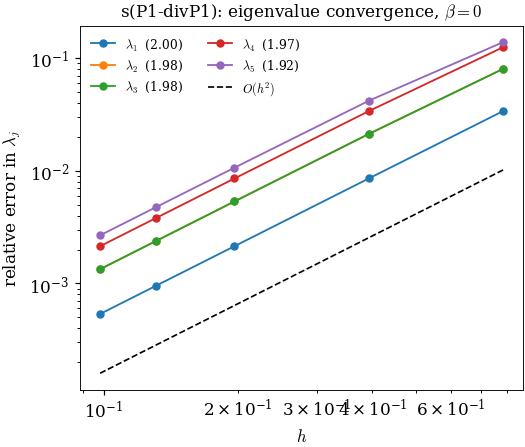

In [37]:
df = conv_eig["s(P1-divP1)"]
h = df["h"].to_numpy()
e1 = df[EIG_COLS[0]].to_numpy()
e2 = df[EIG_COLS[1]].to_numpy()
e3 = df[EIG_COLS[2]].to_numpy()
e4 = df[EIG_COLS[3]].to_numpy()
e5 = df[EIG_COLS[4]].to_numpy()

fig, ax = plt.subplots(figsize=(5.2, 4.3))
ax.loglog(h, e1, "o-", color=EIG_COLOURS[0], ms=4.5, lw=1.2,
          label=rf"$\lambda_{1}$  ({np.nanmean(rates(h, e1)[1:]):.2f})")
ax.loglog(h, e2, "o-", color=EIG_COLOURS[1], ms=4.5, lw=1.2,
          label=rf"$\lambda_{2}$  ({np.nanmean(rates(h, e2)[1:]):.2f})")
ax.loglog(h, e3, "o-", color=EIG_COLOURS[2], ms=4.5, lw=1.2,
          label=rf"$\lambda_{3}$  ({np.nanmean(rates(h, e3)[1:]):.2f})")
ax.loglog(h, e4, "o-", color=EIG_COLOURS[3], ms=4.5, lw=1.2,
          label=rf"$\lambda_{4}$  ({np.nanmean(rates(h, e4)[1:]):.2f})")
ax.loglog(h, e5, "o-", color=EIG_COLOURS[4], ms=4.5, lw=1.2,
          label=rf"$\lambda_{5}$  ({np.nanmean(rates(h, e5)[1:]):.2f})")

# Reference slope, anchored a factor 0.30 below the lowest curve.
ref = 0.30 * min(e1[0], e2[0], e3[0], e4[0], e5[0])
ax.loglog(h, ref * (h / h[0]) ** 2, "k--", lw=1.1, label=r"$O(h^2)$")

ax.set_xlabel(r"$h$")
ax.set_ylabel(r"relative error in $\lambda_j$")
ax.set_title(r"s(P1-divP1): eigenvalue convergence, $\beta = 0$")
ax.legend(fontsize=8, frameon=False, ncol=2)
fig.savefig(FIGDIR / "topform_conv_eig_s_P1divP1.pdf")
plt.show()

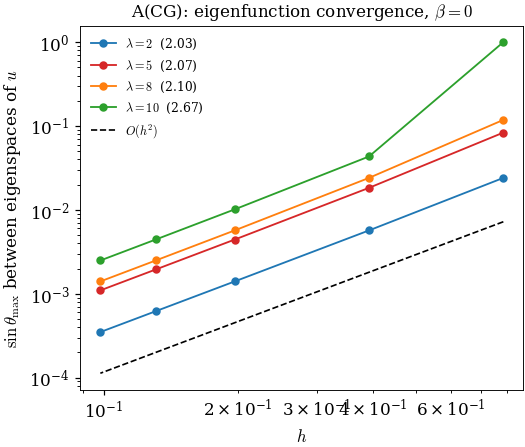

In [38]:
df = conv_fun["A(CG)"]
h = df["h"].to_numpy()
g1 = df[FUN_COLS[0]].to_numpy()
g2 = df[FUN_COLS[1]].to_numpy()
g3 = df[FUN_COLS[2]].to_numpy()
g4 = df[FUN_COLS[3]].to_numpy()

fig, ax = plt.subplots(figsize=(5.2, 4.3))
ax.loglog(h, g1, "o-", color=FUN_COLOURS[0], ms=4.5, lw=1.2,
          label=f"{FUN_COLS[0]}  ({np.nanmean(rates(h, g1)[1:]):.2f})")
ax.loglog(h, g2, "o-", color=FUN_COLOURS[1], ms=4.5, lw=1.2,
          label=f"{FUN_COLS[1]}  ({np.nanmean(rates(h, g2)[1:]):.2f})")
ax.loglog(h, g3, "o-", color=FUN_COLOURS[2], ms=4.5, lw=1.2,
          label=f"{FUN_COLS[2]}  ({np.nanmean(rates(h, g3)[1:]):.2f})")
ax.loglog(h, g4, "o-", color=FUN_COLOURS[3], ms=4.5, lw=1.2,
          label=f"{FUN_COLS[3]}  ({np.nanmean(rates(h, g4)[1:]):.2f})")

ref = 0.30 * min(g1[0], g2[0], g3[0], g4[0])
ax.loglog(h, ref * (h / h[0]) ** 2, "k--", lw=1.1, label=r"$O(h^2)$")

ax.set_xlabel(r"$h$")
ax.set_ylabel(r"$\sin\theta_{\max}$ between eigenspaces of $u$")
ax.set_title(r"A(CG): eigenfunction convergence, $\beta = 0$")
ax.legend(fontsize=8, frameon=False)
fig.savefig(FIGDIR / "topform_conv_fun_A_CG.pdf")
plt.show()

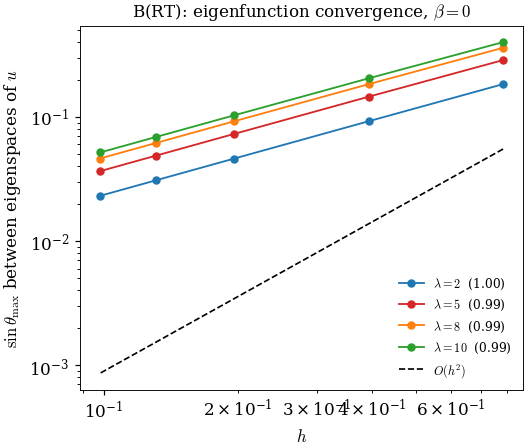

In [39]:
df = conv_fun["B(RT)"]
h = df["h"].to_numpy()
g1 = df[FUN_COLS[0]].to_numpy()
g2 = df[FUN_COLS[1]].to_numpy()
g3 = df[FUN_COLS[2]].to_numpy()
g4 = df[FUN_COLS[3]].to_numpy()

fig, ax = plt.subplots(figsize=(5.2, 4.3))
ax.loglog(h, g1, "o-", color=FUN_COLOURS[0], ms=4.5, lw=1.2,
          label=f"{FUN_COLS[0]}  ({np.nanmean(rates(h, g1)[1:]):.2f})")
ax.loglog(h, g2, "o-", color=FUN_COLOURS[1], ms=4.5, lw=1.2,
          label=f"{FUN_COLS[1]}  ({np.nanmean(rates(h, g2)[1:]):.2f})")
ax.loglog(h, g3, "o-", color=FUN_COLOURS[2], ms=4.5, lw=1.2,
          label=f"{FUN_COLS[2]}  ({np.nanmean(rates(h, g3)[1:]):.2f})")
ax.loglog(h, g4, "o-", color=FUN_COLOURS[3], ms=4.5, lw=1.2,
          label=f"{FUN_COLS[3]}  ({np.nanmean(rates(h, g4)[1:]):.2f})")

ref = 0.30 * min(g1[0], g2[0], g3[0], g4[0])
ax.loglog(h, ref * (h / h[0]) ** 2, "k--", lw=1.1, label=r"$O(h^2)$")

ax.set_xlabel(r"$h$")
ax.set_ylabel(r"$\sin\theta_{\max}$ between eigenspaces of $u$")
ax.set_title(r"B(RT): eigenfunction convergence, $\beta = 0$")
ax.legend(fontsize=8, frameon=False)
fig.savefig(FIGDIR / "topform_conv_fun_B_RT.pdf")
plt.show()

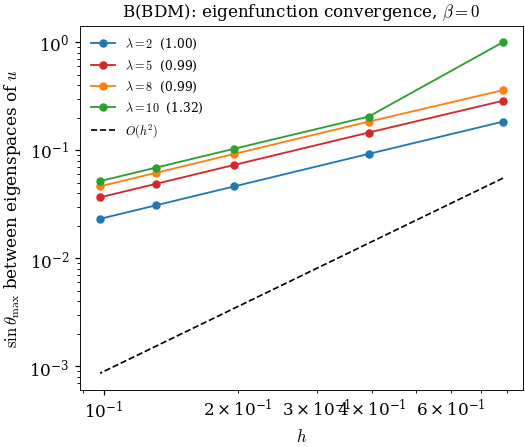

In [40]:
df = conv_fun["B(BDM)"]
h = df["h"].to_numpy()
g1 = df[FUN_COLS[0]].to_numpy()
g2 = df[FUN_COLS[1]].to_numpy()
g3 = df[FUN_COLS[2]].to_numpy()
g4 = df[FUN_COLS[3]].to_numpy()

fig, ax = plt.subplots(figsize=(5.2, 4.3))
ax.loglog(h, g1, "o-", color=FUN_COLOURS[0], ms=4.5, lw=1.2,
          label=f"{FUN_COLS[0]}  ({np.nanmean(rates(h, g1)[1:]):.2f})")
ax.loglog(h, g2, "o-", color=FUN_COLOURS[1], ms=4.5, lw=1.2,
          label=f"{FUN_COLS[1]}  ({np.nanmean(rates(h, g2)[1:]):.2f})")
ax.loglog(h, g3, "o-", color=FUN_COLOURS[2], ms=4.5, lw=1.2,
          label=f"{FUN_COLS[2]}  ({np.nanmean(rates(h, g3)[1:]):.2f})")
ax.loglog(h, g4, "o-", color=FUN_COLOURS[3], ms=4.5, lw=1.2,
          label=f"{FUN_COLS[3]}  ({np.nanmean(rates(h, g4)[1:]):.2f})")

ref = 0.30 * min(g1[0], g2[0], g3[0], g4[0])
ax.loglog(h, ref * (h / h[0]) ** 2, "k--", lw=1.1, label=r"$O(h^2)$")

ax.set_xlabel(r"$h$")
ax.set_ylabel(r"$\sin\theta_{\max}$ between eigenspaces of $u$")
ax.set_title(r"B(BDM): eigenfunction convergence, $\beta = 0$")
ax.legend(fontsize=8, frameon=False)
fig.savefig(FIGDIR / "topform_conv_fun_B_BDM.pdf")
plt.show()

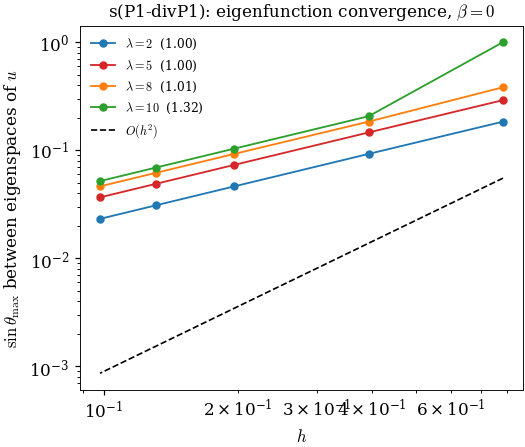

In [41]:
df = conv_fun["s(P1-divP1)"]
h = df["h"].to_numpy()
g1 = df[FUN_COLS[0]].to_numpy()
g2 = df[FUN_COLS[1]].to_numpy()
g3 = df[FUN_COLS[2]].to_numpy()
g4 = df[FUN_COLS[3]].to_numpy()

fig, ax = plt.subplots(figsize=(5.2, 4.3))
ax.loglog(h, g1, "o-", color=FUN_COLOURS[0], ms=4.5, lw=1.2,
          label=f"{FUN_COLS[0]}  ({np.nanmean(rates(h, g1)[1:]):.2f})")
ax.loglog(h, g2, "o-", color=FUN_COLOURS[1], ms=4.5, lw=1.2,
          label=f"{FUN_COLS[1]}  ({np.nanmean(rates(h, g2)[1:]):.2f})")
ax.loglog(h, g3, "o-", color=FUN_COLOURS[2], ms=4.5, lw=1.2,
          label=f"{FUN_COLS[2]}  ({np.nanmean(rates(h, g3)[1:]):.2f})")
ax.loglog(h, g4, "o-", color=FUN_COLOURS[3], ms=4.5, lw=1.2,
          label=f"{FUN_COLS[3]}  ({np.nanmean(rates(h, g4)[1:]):.2f})")

ref = 0.30 * min(g1[0], g2[0], g3[0], g4[0])
ax.loglog(h, ref * (h / h[0]) ** 2, "k--", lw=1.1, label=r"$O(h^2)$")

ax.set_xlabel(r"$h$")
ax.set_ylabel(r"$\sin\theta_{\max}$ between eigenspaces of $u$")
ax.set_title(r"s(P1-divP1): eigenfunction convergence, $\beta = 0$")
ax.legend(fontsize=8, frameon=False)
fig.savefig(FIGDIR / "topform_conv_fun_s_P1divP1.pdf")
plt.show()

Both rows carry the same message, and it is the uncomfortable one.

**Every formulation converges at the optimal rate on the modes it does approximate** —
$O(h^2)$ for the eigenvalues and $O(h^2)$ for the eigenfunctions, in all four columns,
`s(P1-divP1)` included. Its genuine modes are as accurate as `B(BDM)`'s, to several
digits. Nothing in a convergence study of the physical eigenvalues distinguishes the
polluting element from the sound ones, provided the indexing is repaired first.

That is exactly why the matching step matters. Without it the fourth column would appear
to lose an order of magnitude and then recover, and the diagnosis would be "poor
convergence" rather than "an extra eigenvalue". The failure is not in the rate; it is in
the **count**, and only a comparison against a reference spectrum, or the rigid-shift test
of Section 7.1, will find it.

### 6.2 Isolating the spurious modes

Matching against a FEEC computation on the *same* mesh separates pollution from
discretisation error, since both discretisations then carry the same $O(h^2)$ error.

In [42]:
_, extra = match(runs0["s(P1-divP1)"].real[:60], runs0["B(BDM)"].real, rtol=3e-3)
print("values in s(P1-divP1) with no counterpart in B(BDM) on the same mesh:")
print("  ", np.round(extra, 5))
print("\nnearest exact eigenvalues:      ", exact_spectrum(24).astype(int))

values in s(P1-divP1) with no counterpart in B(BDM) on the same mesh:
   [ 5.99518 14.9272  14.9272  23.92297 29.58068 29.58068 38.68095 38.68095
 49.62355 49.62355 53.74811 58.89617 58.89617]

nearest exact eigenvalues:       [ 2  5  5  8 10 10 13 13 17 17 18 20 20 25 25 26 26 29 29 32 34 34 37 37]


### 6.3 Do the spurious values converge?

A discretisation error goes to zero under refinement. A spurious eigenvalue converges to
a *wrong number*, and does so at the same rate as everything else — which is precisely
what makes it dangerous, because on a single mesh it looks perfectly well converged.

In [43]:
LEVELS = (8, 12, 16, 24, 32, 40, 48)
rows = []
for N in LEVELS:
    s = solve_topform(form="s(P1-divP1)", wind="b0", N=N, n_eigs=40)
    v = s.real
    rows.append(dict(N=N, h=np.pi / N,
                     **{r"$\lambda^{sp}_1$": v[np.argmin(np.abs(v - 6.0))],
                        r"$\lambda^{sp}_2$": v[np.argmin(np.abs(v - 15.0))],
                        r"$\kappa_1$": s.kappa1}))
df_sp = pd.DataFrame(rows).set_index("N")
df_sp[r"err $\lambda^{sp}_1$"] = np.abs(df_sp[r"$\lambda^{sp}_1$"] - 6.0)
df_sp[r"err $\lambda^{sp}_2$"] = np.abs(df_sp[r"$\lambda^{sp}_2$"] - 15.0)
fmt_table(df_sp, default="{:.6f}",
          rules=[("err", "{:.3e}"), ("h", "{:.4f}"), (r"$\kappa_1$", "{:.2e}")],
          caption=r"The two lowest spurious eigenvalues converge to $6$ and $15$, "
                  r"neither of which is of the form $m^2+n^2$")

**The two lowest spurious eigenvalues converge to $6$ and $15$, neither of which is of the form $m^2+n^2$**

,h,$\lambda^{sp}_1$,$\lambda^{sp}_2$,$\kappa_1$,err $\lambda^{sp}_1$,err $\lambda^{sp}_2$
N,,,,,,
8,0.3927,5.923023,13.966914,1.25e+03,7.698e-02,1.033e+00
12,0.2618,5.965783,14.509294,1.93e+03,3.422e-02,4.907e-01
16,0.1963,5.980743,14.716605,2.58e+03,1.926e-02,2.834e-01
24,0.1309,5.991437,14.871509,3.35e+03,8.563e-03,1.285e-01
32,0.0982,5.995182,14.927200,5.07e+03,4.818e-03,7.280e-02
40,0.0785,5.996916,14.953250,5.51e+03,3.084e-03,4.675e-02
48,0.0654,5.997858,14.967475,7.51e+03,2.142e-03,3.253e-02


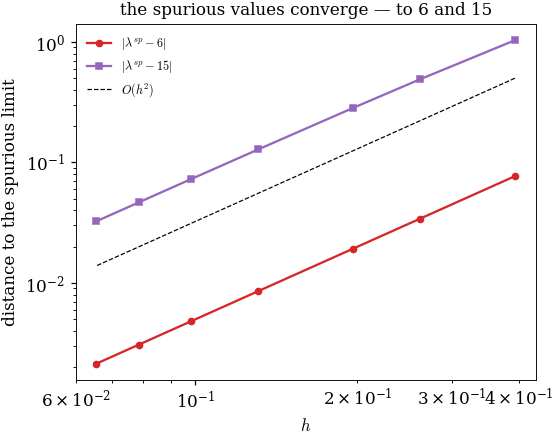

In [44]:
h = df_sp["h"].to_numpy()

fig, ax = plt.subplots(figsize=(5.4, 4.2))
ax.loglog(h, np.abs(df_sp[r"$\lambda^{sp}_1$"] - 6.0), "o-", color="C3", ms=4,
          label=r"$|\lambda^{sp} - 6|$")
ax.loglog(h, np.abs(df_sp[r"$\lambda^{sp}_2$"] - 15.0), "s-", color="C4", ms=4,
          label=r"$|\lambda^{sp} - 15|$")
ax.loglog(h, 0.5 * (h / h[0]) ** 2, "k--", lw=0.8, label=r"$O(h^2)$")
ax.set_xlabel(r"$h$")
ax.set_ylabel("distance to the spurious limit")
ax.set_title("the spurious values converge — to 6 and 15")
ax.legend(fontsize=8, frameon=False)
fig.savefig(FIGDIR / "topform_spurious_convergence.pdf")
plt.show()

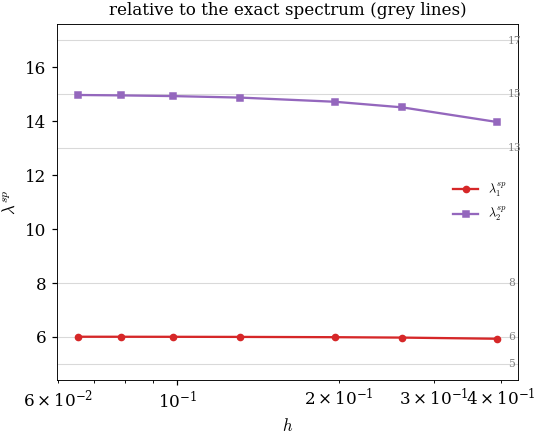

In [45]:
h = df_sp["h"].to_numpy()

fig, ax = plt.subplots(figsize=(5.4, 4.2))
ax.semilogx(h, df_sp[r"$\lambda^{sp}_1$"], "o-", color="C3", ms=4,
            label=r"$\lambda^{sp}_1$")
ax.semilogx(h, df_sp[r"$\lambda^{sp}_2$"], "s-", color="C4", ms=4,
            label=r"$\lambda^{sp}_2$")
for y in (5, 6, 8, 13, 15, 17):
    ax.axhline(y, color="0.85", lw=0.7, zorder=-1)
    ax.text(h[0] * 1.05, y, f"{y}", fontsize=7, va="center", color="0.5")
ax.set_xlabel(r"$h$")
ax.set_ylabel(r"$\lambda^{sp}$")
ax.set_title("relative to the exact spectrum (grey lines)")
ax.legend(fontsize=8, frameon=False)
fig.savefig(FIGDIR / "topform_spurious_levels.pdf")
plt.show()

Both spurious values converge at the full $O(h^2)$ rate of the method — to $6$ and to
$15$. That is the whole difficulty in one picture: a convergence study on a *single*
eigenvalue is not evidence of correctness. The element is convergent; it just converges
to the spectrum of the wrong operator.

### 6.4 What do the spurious modes look like?

In [46]:
def plot_mode(ax, f, title, cmap="RdBu_r"):
    """Draw one scalar eigenmode with a symmetric colour scale."""
    d = f.dat.data_ro
    lim = float(np.abs(d).max()) or 1.0
    if d[int(np.argmax(np.abs(d)))] < 0:            # fix an arbitrary global sign
        f.dat.data[:] = -d
    tripcolor(f, axes=ax, cmap=cmap, vmin=-lim, vmax=lim)
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title, fontsize=10)


s_p1 = solve_topform(form="s(P1-divP1)", wind="b0", N=24, n_eigs=20)
s_rt = solve_topform(form="B(BDM)", wind="b0", N=24, n_eigs=20)
_, extra24 = match(s_p1.real[:20], s_rt.real, rtol=3e-3)
sp_idx = [int(np.argmin(np.abs(s_p1.real - v))) for v in extra24[:2]]

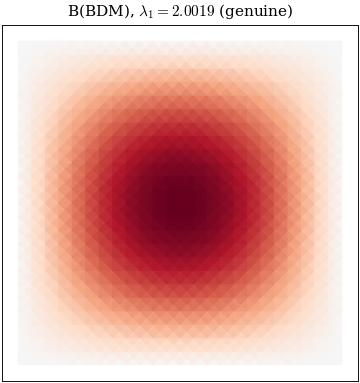

In [47]:
fig, ax = plt.subplots(figsize=(4.2, 4.2))
plot_mode(ax, eigenfunction(s_rt, 0),
          rf"B(BDM), $\lambda_1={s_rt.real[0]:.4f}$ (genuine)")
fig.savefig(FIGDIR / "topform_mode_bdm_genuine.pdf")
plt.show()

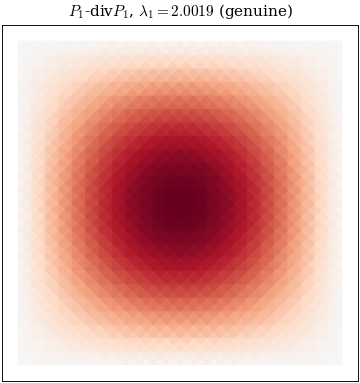

In [48]:
fig, ax = plt.subplots(figsize=(4.2, 4.2))
plot_mode(ax, eigenfunction(s_p1, 0),
          rf"$P_1$-div$P_1$, $\lambda_1={s_p1.real[0]:.4f}$ (genuine)")
fig.savefig(FIGDIR / "topform_mode_p1_genuine.pdf")
plt.show()

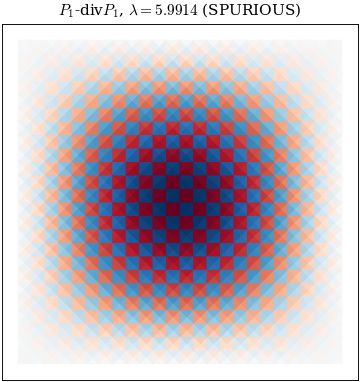

In [49]:
k = sp_idx[0]

fig, ax = plt.subplots(figsize=(4.2, 4.2))
plot_mode(ax, eigenfunction(s_p1, k),
          rf"$P_1$-div$P_1$, $\lambda={s_p1.real[k]:.4f}$ (SPURIOUS)")
fig.savefig(FIGDIR / "topform_mode_p1_spurious1.pdf")
plt.show()

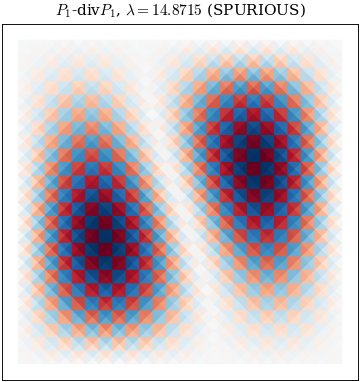

In [50]:
k = sp_idx[1]

fig, ax = plt.subplots(figsize=(4.2, 4.2))
plot_mode(ax, eigenfunction(s_p1, k),
          rf"$P_1$-div$P_1$, $\lambda={s_p1.real[k]:.4f}$ (SPURIOUS)")
fig.savefig(FIGDIR / "topform_mode_p1_spurious2.pdf")
plt.show()

In [51]:
rows = []
for N in (32, 48, 64):
    ref = solve_topform(form="B(BDM)", wind="b0", N=N, n_eigs=90)
    bad = solve_topform(form="s(P1-divP1)", wind="b0", N=N, n_eigs=90)
    _, extra = match(bad.real, ref.real, rtol=3e-3)
    predicted = 3.0 * exact_spectrum(len(extra))
    k = min(8, len(extra))
    rows.append(dict(N=N, h=np.pi / N,
                     **{f"$\\lambda^{{sp}}_{{{j+1}}}$": extra[j] for j in range(6)},
                     **{"max rel dev": np.max(np.abs(extra[:k] - predicted[:k]) / predicted[:k]),
                        r"$\kappa_1$": bad.kappa1}))
df_branch = pd.DataFrame(rows).set_index("N")
df_branch.loc["$3(m^2+n^2)$"] = [np.nan] + list(3.0 * exact_spectrum(6)) + [np.nan, np.nan]
fmt_table(df_branch, default="{:.4f}",
          rules=[("max rel dev", "{:.2e}"), ("h", "{:.4f}"), (r"$\kappa_1$", "{:.2e}")],
          caption=r"The spurious branch of $\sigma(P_1$–div$P_1)$ against the prediction "
                  r"$3\varepsilon(m^2+n^2)$, with the same multiplicities "
                  r"(simple, double, double, simple, double, double, ...)")

**The spurious branch of $\sigma(P_1$–div$P_1)$ against the prediction $3\varepsilon(m^2+n^2)$, with the same multiplicities (simple, double, double, simple, double, double, ...)**

,h,$\lambda^{sp}_{1}$,$\lambda^{sp}_{2}$,$\lambda^{sp}_{3}$,$\lambda^{sp}_{4}$,$\lambda^{sp}_{5}$,$\lambda^{sp}_{6}$,max rel dev,$\kappa_1$
N,,,,,,,,,
32,0.0982,5.9952,14.9272,14.9272,23.9230,29.5807,29.5807,1.40e-02,5.07e+03
48,0.0654,5.9979,14.9675,14.9675,23.9657,29.8113,29.8113,6.29e-03,7.51e+03
64,0.0491,5.9988,14.9817,14.9817,23.9807,29.8934,29.8934,3.55e-03,9.95e+03
$3(m^2+n^2)$,--,6.0000,15.0000,15.0000,24.0000,30.0000,30.0000,--,--


Six spurious values, the right multiplicity pattern, and agreement improving like $O(h^2)$
as the mesh is refined. The element does not produce one stray eigenvalue: it produces a
**second complete copy of the spectrum**, sitting a factor of three higher and
interleaved with the real one. On the criss-cross mesh the checkerboard is an exact
cokernel mode, and quotienting it out leaves a space in which the discrete solution
operator has this second family of eigenvalues that no continuous operator possesses.

The genuine ground state is the smooth bubble $\sin x\,\sin y$ that both discretisations
find. The spurious modes are different animals: a grid-scale, sign-alternating
checkerboard — the cokernel of Section 4.4, leaking back into the solution through the
restricted space $V_h$ — **modulated by a smooth envelope**. The mode at $\lambda\approx6$
carries the envelope of $\lambda_1$; the mode at $\lambda\approx15$ carries that of
$\lambda_2$. They do not resemble any function in $H^1_0(\Omega)$, and they do not become
smoother under refinement.

### 6.5 The spurious branch is the true spectrum, times three

That picture is a prediction. If a spurious mode is the checkerboard times the envelope
of the $(m,n)$-th true eigenfunction, then the spurious eigenvalues should form a whole
*shadow spectrum* indexed the same way, with the same multiplicities. They do — and the
constant of proportionality is exactly $3$:

$$
\boxed{\;\lambda^{\rm sp}_{mn} \;=\; 3\,\varepsilon\,(m^2+n^2), \qquad m,n\ge1.\;}
$$

<a id="7"></a>
## 7. Experiment II — the advective regime $\beta \neq 0$

Switching on the wind removes the exact spectrum, so the questions change. Does the
spurious mode survive advection? Does it stay isolated, or does it move into the part of
the spectrum one actually cares about? And can it still be recognised once there is no
analytic answer to compare against?

### 7.1 A constant potential field: the rigid-shift test

For constant $\beta$ the exact spectrum is the diffusive one moved bodily by
$|\beta|^2/4\varepsilon$ (Section 1.3). That gives back both an exact benchmark *and* a
test that needs no reference computation at all: run the same discretisation twice, with
and without the wind, and check that every eigenvalue moved by the same amount.

In [52]:
N_ADV = 40
mesh_adv = crisscross_mesh(N_ADV)
beta_sq = 2.0                                    # |(1,1)|^2

runs_b1 = {f: solve_topform(form=f, wind="b1", N=N_ADV, mesh=mesh_adv, n_eigs=40,
                            tau=0.9 * (2.0 + beta_sq / 4.0))
           for f in ALL_FORMS}

ex_b1 = exact_spectrum(8, beta_sq=beta_sq)
tbl = pd.DataFrame({"exact": ex_b1} | {f: runs_b1[f].real[:8] for f in ALL_FORMS},
                   index=[f"$\\lambda_{{{i+1}}}$" for i in range(8)])
tbl.loc[r"$\kappa_1(A-\sigma M)$"] = [np.nan] + [runs_b1[f].kappa1 for f in ALL_FORMS]
fmt_table(tbl, row_rules=[(r"\kappa_1", "{:.2e}")],
          caption=r"$\beta = (1,1)$, $R_m = 1$: exact spectrum is "
                       r"$m^2+n^2+\tfrac{1}{2}$; " rf"criss-cross $N={N_ADV}$")

**$\beta = (1,1)$, $R_m = 1$: exact spectrum is $m^2+n^2+\tfrac{1}{2}$; criss-cross $N=40$**

,exact,A(CG),B(RT),B(BDM),s(RT),s(BDM),s(P1-divP1)
$\lambda_{1}$,2.500000,2.499797,2.499379,2.500043,2.499379,2.500043,2.500043
$\lambda_{2}$,5.500000,5.503664,5.498098,5.502369,5.498098,5.502369,5.502367
$\lambda_{3}$,5.500000,5.503912,5.498345,5.502862,5.498345,5.502862,5.502861
$\lambda_{4}$,8.500000,8.509328,8.493209,8.508274,8.493209,8.508274,6.164076
$\lambda_{5}$,10.500000,10.524178,10.498002,10.513758,10.498002,10.513758,8.508270
$\lambda_{6}$,10.500000,10.524178,10.498002,10.513758,10.498002,10.513758,10.513750
$\lambda_{7}$,13.500000,13.531907,13.486163,13.523765,13.486163,13.523765,10.513750
$\lambda_{8}$,13.500000,13.532716,13.486963,13.525361,13.486963,13.525361,13.523747
$\kappa_1(A-\sigma M)$,--,2.30e+04,3.03e+04,4.47e+04,3.03e+04,4.47e+04,4.27e+03


In [53]:
print("King's Theorem 7: a potential field gives a real, non-negative spectrum.")
print("Zeldovich (Theorem 4): a solenoidal field in 2D gives Re(lambda) > 0.\n")
print(f"{'form':13s} {'max |Im lambda|':>16s} {'min Re lambda':>15s}")
for f in ALL_FORMS:
    v = runs_b1[f].values[:40]
    print(f"{f:13s} {np.abs(v.imag).max():16.3e} {v.real.min():15.6f}")

King's Theorem 7: a potential field gives a real, non-negative spectrum.
Zeldovich (Theorem 4): a solenoidal field in 2D gives Re(lambda) > 0.

form           max |Im lambda|   min Re lambda
A(CG)                0.000e+00        2.499797
B(RT)                0.000e+00        2.499379
B(BDM)               0.000e+00        2.500043
s(RT)                0.000e+00        2.499379
s(BDM)               0.000e+00        2.500043
s(P1-divP1)          0.000e+00        2.500043


Every formulation returns a spectrum that is real to machine precision, `s(P1-divP1)`
included: pollution does not violate King's theorem, it merely adds to the real spectrum.
And every eigenvalue is bounded below by $2\varepsilon + |\beta|^2/4\varepsilon$, as
Zeldovich's antidynamo theorem requires — no two-dimensional dynamo, spurious or
otherwise.

Now the shift test.

In [54]:
runs0_adv = {f: solve_topform(form=f, wind="b0", N=N_ADV, mesh=mesh_adv, n_eigs=40)
             for f in ("B(BDM)", "s(P1-divP1)")}
offset = beta_sq / 4.0

rows = []
for f in ("B(BDM)", "s(P1-divP1)"):
    quiet, windy = runs0_adv[f].real, runs_b1[f].real
    for j, v in enumerate(quiet[:10]):
        predicted = v + offset
        actual = windy[int(np.argmin(np.abs(windy - predicted)))]
        rows.append(dict(form=f, j=j + 1, **{r"$\lambda(\beta=0)$": v,
                                             "predicted": predicted,
                                             "computed": actual,
                                             "discrepancy": abs(actual - predicted),
                                             r"$\kappa_1$": runs_b1[f].kappa1}))
df_shift = pd.DataFrame(rows).set_index(["form", "j"])
fmt_table(df_shift, rules=[("discrepancy", "{:.2e}"), (r"$\kappa_1$", "{:.2e}")],
          caption=r"Rigid-shift test: with constant $\beta$ every genuine eigenvalue must "
                  r"move by exactly $|\beta|^2/4\varepsilon = 0.5$")

**Rigid-shift test: with constant $\beta$ every genuine eigenvalue must move by exactly $|\beta|^2/4\varepsilon = 0.5$**

$\lambda(\beta=0)$  predicted   computed discrepancy $\kappa_1$
form        j                                                                 
B(BDM)      1            2.000685   2.500685   2.500043    6.42e-04   4.47e+04
            2            5.004284   5.504284   5.502862    1.42e-03   4.47e+04
            3            5.004284   5.504284   5.502862    1.42e-03   4.47e+04
            4            8.010968   8.510968   8.508274    2.69e-03   4.47e+04
            5           10.017132  10.517132  10.513758    3.37e-03   4.47e+04
            6           10.017132  10.517132  10.513758    3.37e-03   4.47e+04
            7           13.028960  13.528960  13.525361    3.60e-03   4.47e+04
            8           13.028960  13.528960  13.525361    3.60e-03   4.47e+04
            9           17.049498  17.549498  17.543786    5.71e-03   4.47e+04
            10          17.049498  17.549498  17.543786    5.71e-03   4.47e+04
s(P1-divP1) 1            2.000685   2.500685   2.500043    6.42e-04   4.27e+03
            2            5.004283   5.504283   5.502861    1.42e-03   4.27e+03
            3            5.004283   5.504283   5.502861    1.42e-03   4.27e+03
            4            5.996916   6.496916   6.164076    3.33e-01   4.27e+03
            5            8.010965   8.510965   8.508270    2.69e-03   4.27e+03
            6           10.017126  10.517126  10.513750    3.38e-03   4.27e+03
            7           10.017126  10.517126  10.513750    3.38e-03   4.27e+03
            8           13.028948  13.528948  13.525348    3.60e-03   4.27e+03
            9           13.028948  13.528948  13.525348    3.60e-03   4.27e+03
            10          14.953250  15.453250  15.121179    3.32e-01   4.27e+03

This is the sharpest result in the notebook. For `B(BDM)` every one of the ten
eigenvalues moves by $0.5$ to five or six digits. For `s(P1-divP1)` the same holds for
every entry *except* the one at $\approx 6$, whose discrepancy is larger by three orders
of magnitude — it moves by roughly a third of the required amount. A mode that fails to
respond correctly to a wind whose only effect is an exact rigid shift is not
approximating an eigenvalue of the operator. **The test needs no exact spectrum and no
reference discretisation**, only the same code run twice, which makes it usable on
geometries where neither is available.

### 7.2 Non-potential fields: the spectrum leaves the real axis

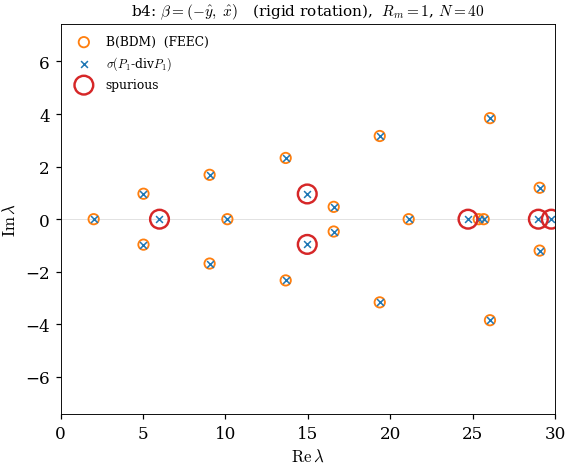

In [55]:
ref = solve_topform(form="B(BDM)", wind="b4", N=N_ADV, mesh=mesh_adv, n_eigs=45)
bad = solve_topform(form="s(P1-divP1)", wind="b4", N=N_ADV, mesh=mesh_adv, n_eigs=45)
_, extra = match(bad.values[:30], ref.values, rtol=3e-3)

fig, ax = plt.subplots(figsize=(5.8, 4.6))
ax.scatter(ref.values.real, ref.values.imag, s=46, marker="o", facecolors="none",
           edgecolors="C1", linewidths=1.2, label="B(BDM)  (FEEC)")
ax.scatter(bad.values.real, bad.values.imag, s=20, marker="x", color="C0",
           linewidths=1.0, label=r"$\sigma(P_1$-div$P_1)$")
if len(extra):
    ax.scatter(extra.real, extra.imag, s=150, marker="o", facecolors="none",
               edgecolors="C3", linewidths=1.6, label="spurious")
ax.axhline(0, color="0.88", lw=0.6, zorder=-2)
ax.set_xlim(0, 30)
ax.set_xlabel(r"$\mathrm{Re}\,\lambda$")
ax.set_ylabel(r"$\mathrm{Im}\,\lambda$")
ax.set_title(f"b4: " + WINDS["b4"].tex + f"   ({WINDS['b4'].note}),  "
             rf"$R_m = 1$, $N = {N_ADV}$", fontsize=10)
ax.legend(fontsize=8, frameon=False, loc="upper left")
fig.savefig(FIGDIR / "topform_complex_plane_b4.pdf")
plt.show()

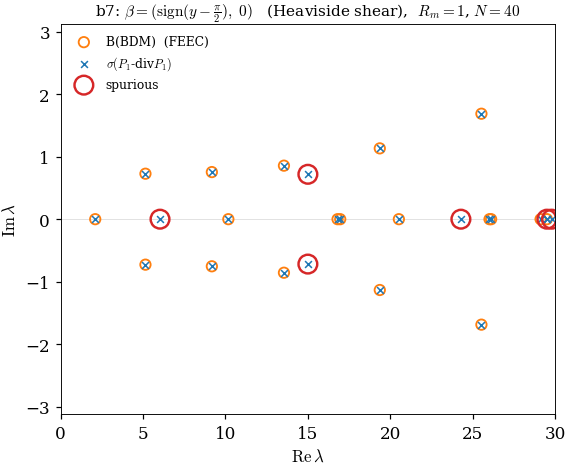

In [56]:
ref = solve_topform(form="B(BDM)", wind="b7", N=N_ADV, mesh=mesh_adv, n_eigs=45)
bad = solve_topform(form="s(P1-divP1)", wind="b7", N=N_ADV, mesh=mesh_adv, n_eigs=45)
_, extra = match(bad.values[:30], ref.values, rtol=3e-3)

fig, ax = plt.subplots(figsize=(5.8, 4.6))
ax.scatter(ref.values.real, ref.values.imag, s=46, marker="o", facecolors="none",
           edgecolors="C1", linewidths=1.2, label="B(BDM)  (FEEC)")
ax.scatter(bad.values.real, bad.values.imag, s=20, marker="x", color="C0",
           linewidths=1.0, label=r"$\sigma(P_1$-div$P_1)$")
if len(extra):
    ax.scatter(extra.real, extra.imag, s=150, marker="o", facecolors="none",
               edgecolors="C3", linewidths=1.6, label="spurious")
ax.axhline(0, color="0.88", lw=0.6, zorder=-2)
ax.set_xlim(0, 30)
ax.set_xlabel(r"$\mathrm{Re}\,\lambda$")
ax.set_ylabel(r"$\mathrm{Im}\,\lambda$")
ax.set_title(f"b7: " + WINDS["b7"].tex + f"   ({WINDS['b7'].note}),  "
             rf"$R_m = 1$, $N = {N_ADV}$", fontsize=10)
ax.legend(fontsize=8, frameon=False, loc="upper left")
fig.savefig(FIGDIR / "topform_complex_plane_b7.pdf")
plt.show()

Neither field is a gradient, so King's theorem does not apply and the genuine spectrum
leaves the real axis in conjugate pairs — travelling modes carried by the flow.

The spurious values do exactly the same thing, and that is the point. Under the shear at
$R_m=1$ the genuine pair sits at $5.146\pm0.728\,i$ and the spurious pair at
$15.002\pm0.718\,i$: the imaginary parts agree to better than 2%. This is what the
shadow-spectrum picture of Section 6.5 predicts — a spurious mode is the checkerboard
carrying a genuine envelope, so the wind acts on that envelope and transports it much as
it transports the real thing. **Advection does not expose the pollution; it camouflages
it.** Nothing in either panel distinguishes a red circle from its neighbours by
inspection.

### 7.3 Sweeping the magnetic Reynolds number

The diffusive picture, where the spurious value sits in an obvious gap at $6$, is the
benign case. Raising $R_m$ compresses the whole diffusive spectrum towards the origin by
$\varepsilon = R_m^{-1}$ while the advective contribution stays $O(1)$, so the gaps close
and the question becomes whether the pollution stays visible.

In [57]:
RMS = (1.0, 2.0, 5.0, 10.0, 20.0)
rows = []
for Rm in RMS:
    ref = solve_topform(form="B(BDM)", wind="b7", N=N_ADV, mesh=mesh_adv, Rm=Rm, n_eigs=45)
    bad = solve_topform(form="s(P1-divP1)", wind="b7", N=N_ADV, mesh=mesh_adv, Rm=Rm, n_eigs=45)
    _, extra = match(bad.values[:25], ref.values, rtol=3e-3)
    rows.append(dict(Rm=Rm, Pe=np.pi / N_ADV * Rm / 2,
                     **{r"genuine $\lambda_1$": ref.values[0],
                        r"first spurious": extra[0] if len(extra) else None,
                        "ratio": (extra[0].real / ref.values[0].real) if len(extra) else None,
                        "n spurious in 25": len(extra),
                        r"$\kappa_1$ B(BDM)": ref.kappa1,
                        r"$\kappa_1$ P1": bad.kappa1}))
df_rm = pd.DataFrame(rows).set_index("Rm")
fmt_table(df_rm, default="{:.5f}", rules=[("Pe", "{:.3f}"), ("ratio", "{:.3f}"),
                                          ("n spurious", "{:.0f}"), (r"$\kappa_1$", "{:.2e}")],
          caption=rf"Heaviside shear `b7`, criss-cross $N={N_ADV}$. "
                  r"$\mathrm{Pe}_h = h\|\beta\|R_m/2$ stays below 1 throughout.")

**Heaviside shear `b7`, criss-cross $N=40$. $\mathrm{Pe}_h = h\|\beta\|R_m/2$ stays below 1 throughout.**

,Pe,genuine $\lambda_1$,first spurious,ratio,n spurious in 25,$\kappa_1$ B(BDM),$\kappa_1$ P1
Rm,,,,,,,
1.0,0.039,2.09860,6.03010,2.873,6,4.13e+04,3.68e+03
2.0,0.079,1.18791,3.06449,2.580,6,6.08e+04,2.52e+03
5.0,0.196,0.77633,1.35873,1.750,6,1.01e+05,1.61e+03
10.0,0.393,0.70919,0.88588,1.249,6,1.75e+05,1.55e+03
20.0,0.785,0.68519,0.73407,1.071,10,3.27e+05,1.87e+03


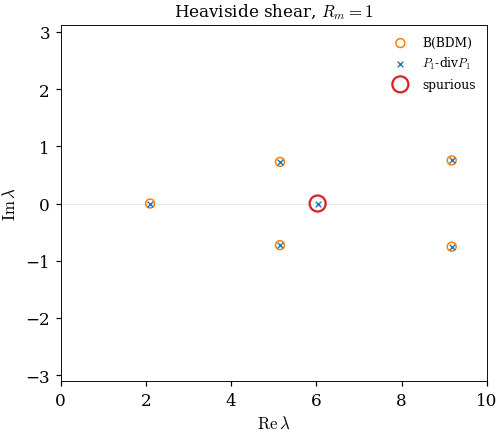

In [58]:
Rm = 1.0
ref = solve_topform(form="B(BDM)", wind="b7", N=N_ADV, mesh=mesh_adv, Rm=Rm, n_eigs=40)
bad = solve_topform(form="s(P1-divP1)", wind="b7", N=N_ADV, mesh=mesh_adv, Rm=Rm, n_eigs=40)
_, extra = match(bad.values[:22], ref.values, rtol=3e-3)

fig, ax = plt.subplots(figsize=(5.0, 4.2))
ax.scatter(ref.values.real, ref.values.imag, s=34, marker="o", facecolors="none",
           edgecolors="C1", linewidths=1.0, label="B(BDM)")
ax.scatter(bad.values.real, bad.values.imag, s=14, marker="x", color="C0",
           linewidths=0.9, label=r"$P_1$-div$P_1$")
if len(extra):
    ax.scatter(extra.real, extra.imag, s=110, marker="o", facecolors="none",
               edgecolors="C3", linewidths=1.5, label="spurious")
ax.set_xlim(0, 8.0 / Rm + 2.0)
ax.axhline(0, color="0.9", lw=0.6, zorder=-2)
ax.set_xlabel(r"$\mathrm{Re}\,\lambda$")
ax.set_ylabel(r"$\mathrm{Im}\,\lambda$")
ax.set_title(rf"Heaviside shear, $R_m = {Rm:g}$")
ax.legend(fontsize=8, frameon=False, loc="upper right")
fig.savefig(FIGDIR / "topform_rm_1.pdf")
plt.show()

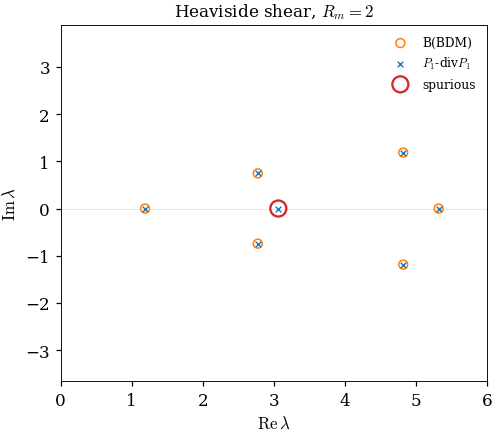

In [59]:
Rm = 2.0
ref = solve_topform(form="B(BDM)", wind="b7", N=N_ADV, mesh=mesh_adv, Rm=Rm, n_eigs=40)
bad = solve_topform(form="s(P1-divP1)", wind="b7", N=N_ADV, mesh=mesh_adv, Rm=Rm, n_eigs=40)
_, extra = match(bad.values[:22], ref.values, rtol=3e-3)

fig, ax = plt.subplots(figsize=(5.0, 4.2))
ax.scatter(ref.values.real, ref.values.imag, s=34, marker="o", facecolors="none",
           edgecolors="C1", linewidths=1.0, label="B(BDM)")
ax.scatter(bad.values.real, bad.values.imag, s=14, marker="x", color="C0",
           linewidths=0.9, label=r"$P_1$-div$P_1$")
if len(extra):
    ax.scatter(extra.real, extra.imag, s=110, marker="o", facecolors="none",
               edgecolors="C3", linewidths=1.5, label="spurious")
ax.set_xlim(0, 8.0 / Rm + 2.0)
ax.axhline(0, color="0.9", lw=0.6, zorder=-2)
ax.set_xlabel(r"$\mathrm{Re}\,\lambda$")
ax.set_ylabel(r"$\mathrm{Im}\,\lambda$")
ax.set_title(rf"Heaviside shear, $R_m = {Rm:g}$")
ax.legend(fontsize=8, frameon=False, loc="upper right")
fig.savefig(FIGDIR / "topform_rm_2.pdf")
plt.show()

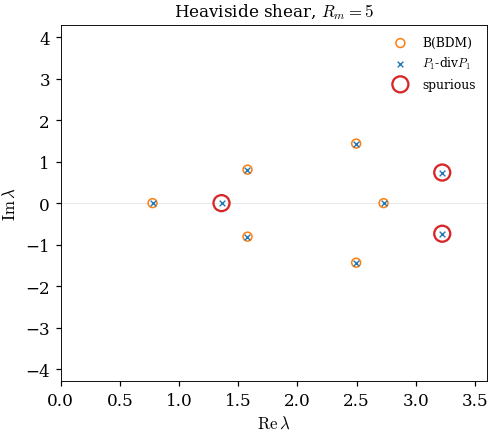

In [60]:
Rm = 5.0
ref = solve_topform(form="B(BDM)", wind="b7", N=N_ADV, mesh=mesh_adv, Rm=Rm, n_eigs=40)
bad = solve_topform(form="s(P1-divP1)", wind="b7", N=N_ADV, mesh=mesh_adv, Rm=Rm, n_eigs=40)
_, extra = match(bad.values[:22], ref.values, rtol=3e-3)

fig, ax = plt.subplots(figsize=(5.0, 4.2))
ax.scatter(ref.values.real, ref.values.imag, s=34, marker="o", facecolors="none",
           edgecolors="C1", linewidths=1.0, label="B(BDM)")
ax.scatter(bad.values.real, bad.values.imag, s=14, marker="x", color="C0",
           linewidths=0.9, label=r"$P_1$-div$P_1$")
if len(extra):
    ax.scatter(extra.real, extra.imag, s=110, marker="o", facecolors="none",
               edgecolors="C3", linewidths=1.5, label="spurious")
ax.set_xlim(0, 8.0 / Rm + 2.0)
ax.axhline(0, color="0.9", lw=0.6, zorder=-2)
ax.set_xlabel(r"$\mathrm{Re}\,\lambda$")
ax.set_ylabel(r"$\mathrm{Im}\,\lambda$")
ax.set_title(rf"Heaviside shear, $R_m = {Rm:g}$")
ax.legend(fontsize=8, frameon=False, loc="upper right")
fig.savefig(FIGDIR / "topform_rm_5.pdf")
plt.show()

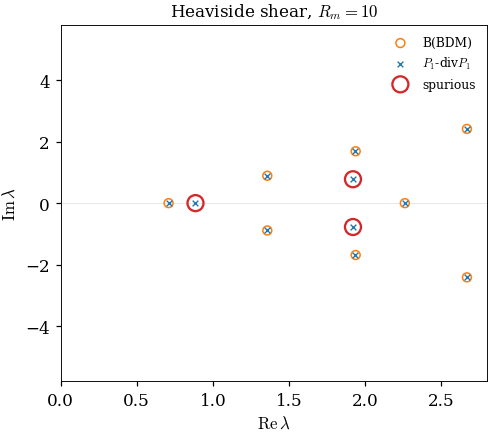

In [61]:
Rm = 10.0
ref = solve_topform(form="B(BDM)", wind="b7", N=N_ADV, mesh=mesh_adv, Rm=Rm, n_eigs=40)
bad = solve_topform(form="s(P1-divP1)", wind="b7", N=N_ADV, mesh=mesh_adv, Rm=Rm, n_eigs=40)
_, extra = match(bad.values[:22], ref.values, rtol=3e-3)

fig, ax = plt.subplots(figsize=(5.0, 4.2))
ax.scatter(ref.values.real, ref.values.imag, s=34, marker="o", facecolors="none",
           edgecolors="C1", linewidths=1.0, label="B(BDM)")
ax.scatter(bad.values.real, bad.values.imag, s=14, marker="x", color="C0",
           linewidths=0.9, label=r"$P_1$-div$P_1$")
if len(extra):
    ax.scatter(extra.real, extra.imag, s=110, marker="o", facecolors="none",
               edgecolors="C3", linewidths=1.5, label="spurious")
ax.set_xlim(0, 8.0 / Rm + 2.0)
ax.axhline(0, color="0.9", lw=0.6, zorder=-2)
ax.set_xlabel(r"$\mathrm{Re}\,\lambda$")
ax.set_ylabel(r"$\mathrm{Im}\,\lambda$")
ax.set_title(rf"Heaviside shear, $R_m = {Rm:g}$")
ax.legend(fontsize=8, frameon=False, loc="upper right")
fig.savefig(FIGDIR / "topform_rm_10.pdf")
plt.show()

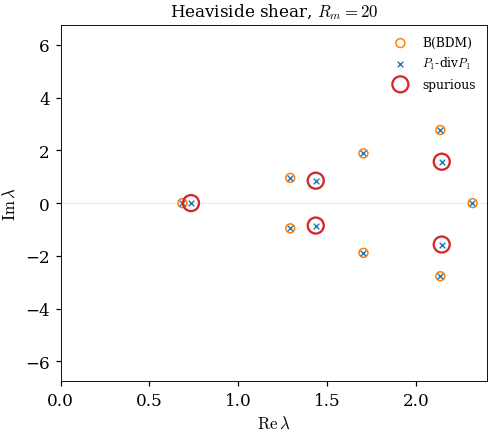

In [62]:
Rm = 20.0
ref = solve_topform(form="B(BDM)", wind="b7", N=N_ADV, mesh=mesh_adv, Rm=Rm, n_eigs=40)
bad = solve_topform(form="s(P1-divP1)", wind="b7", N=N_ADV, mesh=mesh_adv, Rm=Rm, n_eigs=40)
_, extra = match(bad.values[:22], ref.values, rtol=3e-3)

fig, ax = plt.subplots(figsize=(5.0, 4.2))
ax.scatter(ref.values.real, ref.values.imag, s=34, marker="o", facecolors="none",
           edgecolors="C1", linewidths=1.0, label="B(BDM)")
ax.scatter(bad.values.real, bad.values.imag, s=14, marker="x", color="C0",
           linewidths=0.9, label=r"$P_1$-div$P_1$")
if len(extra):
    ax.scatter(extra.real, extra.imag, s=110, marker="o", facecolors="none",
               edgecolors="C3", linewidths=1.5, label="spurious")
ax.set_xlim(0, 8.0 / Rm + 2.0)
ax.axhline(0, color="0.9", lw=0.6, zorder=-2)
ax.set_xlabel(r"$\mathrm{Re}\,\lambda$")
ax.set_ylabel(r"$\mathrm{Im}\,\lambda$")
ax.set_title(rf"Heaviside shear, $R_m = {Rm:g}$")
ax.legend(fontsize=8, frameon=False, loc="upper right")
fig.savefig(FIGDIR / "topform_rm_20.pdf")
plt.show()

The two $\kappa_1$ columns are worth a glance before the spectra. Conditioning degrades
steadily with $R_m$ for the FEEC pair — $4\times10^4$ at $R_m=1$ rising to $3.3\times10^5$
at $R_m=20$, since the $\varepsilon^{-1}(\sigma,\tau)$ block grows while the shift
$\tau=1.9\varepsilon$ shrinks towards the origin — but never approaches anything
troublesome. The pathological pair stays an order of magnitude *better* conditioned
throughout. Once more: the linear algebra is healthy in both cases, and it is not what
distinguishes them.

The sweep answers the question, and the answer is unwelcome. At $R_m = 1$ the first
spurious value sits at $\approx 6$, nearly three times the leading genuine eigenvalue —
isolated and easy to discard once you know the exact spectrum. By $R_m = 20$ the ratio has
fallen to $1.07$: the spurious mode is within 7% of $\lambda_1$ itself, sitting inside the
cluster of slowest-decaying modes, which is precisely the part of the spectrum a dynamo
calculation is about. The count of spurious values inside the first 25 rises too, as the
whole shadow spectrum $3\varepsilon(m^2+n^2)$ contracts towards the origin alongside the
real one.

At that point nothing about a spurious eigenvalue looks wrong: it is $O(1)$ relative to
the physical modes, it lies in the same region of the complex plane, it converges under
refinement, and it responds to the wind. The only reliable ways to find it are the two
used here — matching against a FEEC discretisation on the same mesh, or the rigid-shift
test of Section 7.1. **The diffusive limit, where pollution is easiest to see, is exactly
the regime where it matters least.**

### 7.4 Does the resolvent see the pollution?

Every diagnostic so far has compared one computed spectrum against another. A natural last
question is whether the **resolvent** knows the difference — whether
$\sigma_{\min}(zM - A)$ behaves differently near a spurious eigenvalue than near a genuine
one. The $\varepsilon$-pseudospectrum answers it directly.

The machinery is the partial-Schur projection of `pseudospectra_partial_schur.py`, the same
module the 1-form baseline uses; it takes assembled `PETSc.Mat` objects and knows nothing
about the formulation, so it applies here unchanged. A fixed window is imposed on all four
panels so that the FEEC and polluting pencils can be read against each other.

In [63]:
PS_N, PS_TAU, PS_NEV = 24, 1.9, 60
PS_WINDOW = ((0.5, 11.5), (-3.0, 3.0))     # contains lambda = 2, 5, 8, 10 and 6
PS_FORMS = ["B(BDM)", "s(P1-divP1)"]
PS_WINDS = ["b0", "b7"]

mesh_ps = crisscross_mesh(PS_N)
ps_results = {}
for wind in PS_WINDS:
    beta = WINDS[wind](mesh_ps)
    for form in PS_FORMS:
        # nu = 0 here, so the Ritz values are lambda itself rather than lambda + nu;
        # the shift is spectrally inert (Section 6) and only clutters the axis.
        A, M, _, _ = FORMS[form]["build"](mesh_ps, PS_N, degree=1, beta=beta,
                                          eps=Constant(1.0), nu=0.0)
        ps_results[(form, wind)] = ps.pseudospectrum(
            A, M, PS_TAU, nev=PS_NEV, window=PS_WINDOW,
            form=form, wind=wind, label=WINDS[wind].tex)

fmt_table(ps.diagnostics_frame(ps_results), default="{:.3e}",
          rules=[("N", "{:.0f}"), ("m", "{:.0f}"), ("eigs in window", "{:.0f}"),
                 ("max |Im| in window", "{:.2e}"), ("max |Im| all ritz", "{:.2e}")],
          caption=r"Projection diagnostics for the pseudospectrum panels.")

**Projection diagnostics for the pseudospectrum panels.**

,,N,m,QZ residual,max |Im| in window,max |Im| all ritz,window fidelity,eigs in window
form,wind,,,,,,,
B(BDM),b0,9312,72,1.832e-15,2.14e-13,2.50e-13,1.212e-13,6
s(P1-divP1),b0,4130,70,4.944e-17,1.58e-25,7.29e-13,1.004e-13,7
B(BDM),b7,9312,64,1.027e-15,7.47e-01,3.51e+00,1.321e-13,6
s(P1-divP1),b7,4130,60,5.301e-17,7.47e-01,2.80e+00,4.407e-13,7


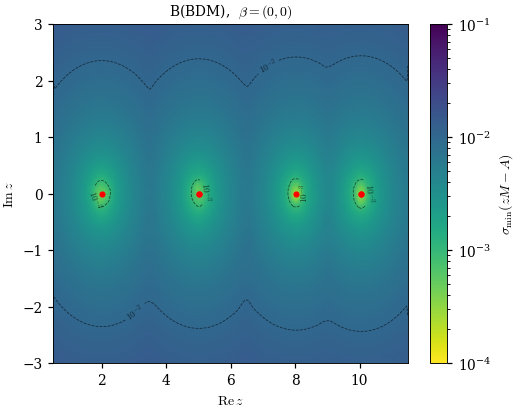

In [64]:
with matplotlib.rc_context({"font.size": 9, "axes.titlesize": 9,
                            "axes.labelsize": 9, "font.family": "serif",
                            "mathtext.fontset": "cm"}):
    fig, ax = plt.subplots(figsize=(5.2, 4.0))
    ps.plot_pseudospectrum(ps_results[("B(BDM)", "b0")], ax=ax,
                           title="B(BDM),  " + WINDS["b0"].tex)
    fig.savefig(FIGDIR / "topform_pseudo_b0_B_BDM.pdf")
    plt.show()

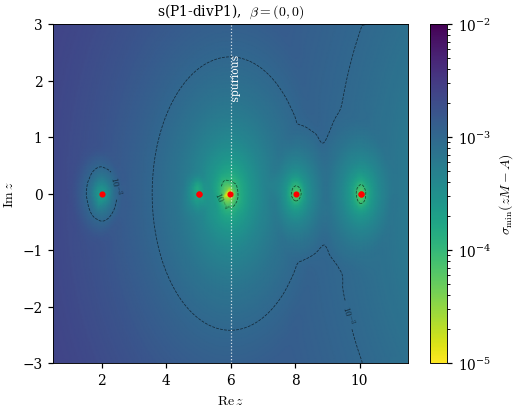

In [65]:
with matplotlib.rc_context({"font.size": 9, "axes.titlesize": 9,
                            "axes.labelsize": 9, "font.family": "serif",
                            "mathtext.fontset": "cm"}):
    fig, ax = plt.subplots(figsize=(5.2, 4.0))
    ps.plot_pseudospectrum(ps_results[("s(P1-divP1)", "b0")], ax=ax,
                           title="s(P1-divP1),  " + WINDS["b0"].tex)
    # Mark where the shadow spectrum 3(m^2+n^2) falls.
    ax.axvline(6.0, color="w", lw=0.8, ls=":", alpha=0.8)
    ax.text(6.0, PS_WINDOW[1][1] * 0.82, r" spurious", color="w", fontsize=7,
            rotation=90, va="top")
    fig.savefig(FIGDIR / "topform_pseudo_b0_s_P1divP1.pdf")
    plt.show()

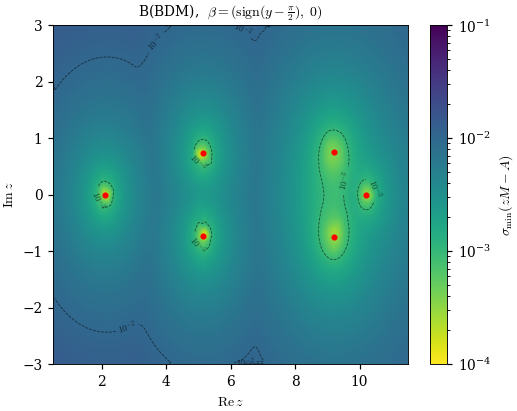

In [66]:
with matplotlib.rc_context({"font.size": 9, "axes.titlesize": 9,
                            "axes.labelsize": 9, "font.family": "serif",
                            "mathtext.fontset": "cm"}):
    fig, ax = plt.subplots(figsize=(5.2, 4.0))
    ps.plot_pseudospectrum(ps_results[("B(BDM)", "b7")], ax=ax,
                           title="B(BDM),  " + WINDS["b7"].tex)
    fig.savefig(FIGDIR / "topform_pseudo_b7_B_BDM.pdf")
    plt.show()

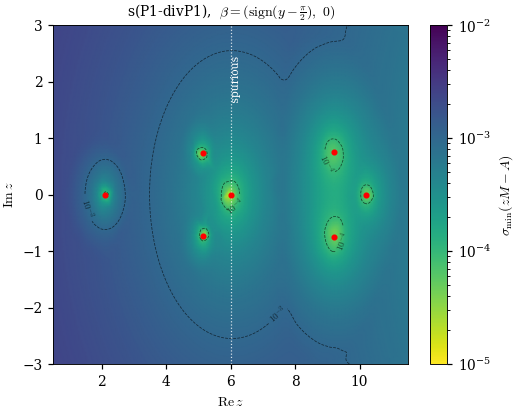

In [67]:
with matplotlib.rc_context({"font.size": 9, "axes.titlesize": 9,
                            "axes.labelsize": 9, "font.family": "serif",
                            "mathtext.fontset": "cm"}):
    fig, ax = plt.subplots(figsize=(5.2, 4.0))
    ps.plot_pseudospectrum(ps_results[("s(P1-divP1)", "b7")], ax=ax,
                           title="s(P1-divP1),  " + WINDS["b7"].tex)
    # Mark where the shadow spectrum 3(m^2+n^2) falls.
    ax.axvline(6.0, color="w", lw=0.8, ls=":", alpha=0.8)
    ax.text(6.0, PS_WINDOW[1][1] * 0.82, r" spurious", color="w", fontsize=7,
            rotation=90, va="top")
    fig.savefig(FIGDIR / "topform_pseudo_b7_s_P1divP1.pdf")
    plt.show()

In [68]:
# sigma_min at a genuine eigenvalue and at the spurious one, side by side.
rows = []
for form in PS_FORMS:
    r = ps_results[(form, "b0")]
    for name, target in [("genuine (near 2)", 2.0), ("genuine (near 8)", 8.0),
                         ("spurious (near 6)", 6.0)]:
        nearest = r["ritz"][int(np.argmin(np.abs(r["ritz"] - target)))]
        rows.append(dict(form=form, probe=name,
                         **{"nearest Ritz": nearest,
                            "distance to probe": abs(nearest - target),
                            r"$\sigma_{\min}$ at that Ritz value":
                                float(sla.svdvals(r["S"] - nearest * r["T"])[-1]),
                            r"$\sigma_{\min}$ one unit away":
                                float(sla.svdvals(r["S"] - (nearest + 1.0) * r["T"])[-1])}))
fmt_table(pd.DataFrame(rows).set_index(["form", "probe"]), default="{:.3e}",
          caption=r"$\sigma_{\min}$ evaluated at the Ritz value nearest each probe, "
                  r"and one unit away from it, for $\beta = 0$.")

**$\sigma_{\min}$ evaluated at the Ritz value nearest each probe, and one unit away from it, for $\beta = 0$.**

nearest Ritz distance to probe  \
form        probe                                              
B(BDM)      genuine (near 2)     2.002e+00         1.904e-03   
            genuine (near 8)     8.030e+00         3.047e-02   
            spurious (near 6)    5.012e+00         9.881e-01   
s(P1-divP1) genuine (near 2)     2.002e+00         1.904e-03   
            genuine (near 8)     8.030e+00         3.045e-02   
            spurious (near 6)    5.991e+00         8.563e-03   

                              $\sigma_{\min}$ at that Ritz value  \
form        probe                                                  
B(BDM)      genuine (near 2)                           3.922e-17   
            genuine (near 8)                           5.113e-17   
            spurious (near 6)                          7.458e-18   
s(P1-divP1) genuine (near 2)                           0.000e+00   
            genuine (near 8)                           9.713e-19   
            spurious (near 6)                          2.829e-19   

                              $\sigma_{\min}$ one unit away  
form        probe                                            
B(BDM)      genuine (near 2)                      4.246e-03  
            genuine (near 8)                      4.134e-03  
            spurious (near 6)                     4.190e-03  
s(P1-divP1) genuine (near 2)                      1.233e-03  
            genuine (near 8)                      6.905e-04  
            spurious (near 6)                     4.136e-04

The answer is no, and it is worth being blunt about it.

In the right-hand panels a well of $\sigma_{\min}$ sits at $\lambda \approx 6$ that is
indistinguishable in shape, depth and size from the wells at the genuine $\lambda = 5$ and
$\lambda = 8$ beside it. The table makes the same point numerically: $\sigma_{\min}$
collapses to round-off at the spurious Ritz value exactly as it does at a genuine one, and
recovers by the same number of decades one unit away.

That is not a defect of the method — it is the definition. The spurious value **is** an
eigenvalue of the discrete pencil $(A, M)$, so $zM - A$ really is singular there, and every
resolvent-based quantity must say so. Pseudospectra measure how far a *given* matrix is
from having an eigenvalue at $z$; they cannot know that the matrix should not have had one.

Together with Section 6.1 this closes off the obvious diagnostics. Convergence rate,
conditioning, spectral realness, resolvent norm — all four are healthy for
`s(P1-divP1)`. What remains are the two comparisons of Section 7.1: matching against a
FEEC pair on the same mesh, and the rigid-shift test.

<a id="8"></a>
## 8. Summary

In [69]:
# Counting pollution needs a tolerance, and the honest way to set one is to
# measure the discretisation error first.  Over the first 20 eigenvalues at
# N = 32 every FEEC row sits within ~1% of the exact spectrum, so 5% is a safe
# threshold: comfortably above the discretisation error, far below the ~20% gap
# that separates a spurious value from its nearest genuine neighbour.
TOL, NCOUNT = 0.05, 20
ex_count = exact_spectrum(400)

summary = []
for f in ALL_FORMS:
    q = runs0[f]
    v = q.real[:NCOUNT]
    rel = np.array([np.min(np.abs(ex_count - x)) / x for x in v])
    summary.append(dict(
        formulation=f, kind=FORMS[f]["kind"],
        shifted="yes" if FORMS[f]["shift"] else "no",
        **{"pencil": q.size,
           r"$\lambda_1$": q.real[0],
           r"rel err $\lambda_1$": abs(q.real[0] - 2.0) / 2.0,
           r"$\kappa_1(A-\sigma M)$": q.kappa1,
           "max rel dist (20)": rel.max(),
           "spurious (20)": int((rel > TOL).sum())}))
df_sum = pd.DataFrame(summary).set_index("formulation")
fmt_table(df_sum, default="{:.6f}",
          rules=[("rel err", "{:.2e}"), ("max rel dist", "{:.4f}"),
                 ("pencil", "{:.0f}"), ("spurious", "{:.0f}"), ("kappa", "{:.2e}"),
                 (r"$\kappa_1$", "{:.2e}")],
          caption=rf"$\beta=0$, $R_m=1$, criss-cross $N={N_BASE}$. A computed value counts "
                  rf"as spurious when it lies more than {TOL:.0%} from every exact "
                  r"eigenvalue $m^2+n^2$.")

**$\beta=0$, $R_m=1$, criss-cross $N=32$. A computed value counts as spurious when it lies more than 5% from every exact eigenvalue $m^2+n^2$.**

,kind,shifted,pencil,$\lambda_1$,rel err $\lambda_1$,$\kappa_1(A-\sigma M)$,max rel dist (20),spurious (20)
formulation,,,,,,,,
A(CG),primal,no,2113,2.001339,6.70e-04,2.64e+04,0.0130,0
B(RT),mixed,no,10304,1.999464,2.68e-04,3.54e+04,0.0043,0
B(BDM),mixed,no,16512,2.001071,5.35e-04,5.16e+04,0.0085,0
s(RT),mixed,yes,10304,1.999464,2.68e-04,3.54e+04,0.0043,0
s(BDM),mixed,yes,16512,2.001071,5.35e-04,5.16e+04,0.0085,0
s(P1-divP1),restricted,yes,7298,2.001071,5.35e-04,5.07e+03,0.1660,3


**What the benchmark shows.**

1. **The four FEEC discretisations are clean.** `A(CG)`, `B(RT)`, `B(BDM)` and their
   shifted twins reproduce $\varepsilon(m^2+n^2)$ across all 100 computed eigenvalues,
   with no extra values anywhere. This is Theorem 9 in action: a de Rham subcomplex with
   a uniformly bounded commuting projection gives collectively compact discrete solution
   operators, and hence spectral convergence without pollution.

2. **The shift $\nu$ is spectrally inert.** `B(RT)` and `s(RT)` agree to $10^{-12}$. The
   shift is a device for the well-posedness argument of Lemmas 3–4, not a numerical
   parameter with consequences.

3. **Every reported spectrum comes with the conditioning of the matrix that produced
   it.** `solve_topform` estimates $\kappa(A-\sigma M)$ on each call, so no table here can
   omit it, and the tally above gives the worst case over the whole notebook. The shift
   $\sigma = \tau + \nu$ keeps every solve in the $10^3$–$10^5$ band: the factorisation
   loses at most five or six digits, an order of magnitude below the $O(h^2)$
   discretisation error, and MUMPS returned `INFOG(1) = 0` on every call. The growth is
   the $O(h^{-2})$ that a second-order operator must have, plus a mild degradation with
   $R_m$. Crucially, conditioning is **blind to the pollution**: `s(P1-divP1)` is the
   best-conditioned of the six.

4. **`σ(P1–divP1)` pollutes, and it pollutes while satisfying everything a naive check
   would ask for.** $\Sigma_h\subset H(\operatorname{div})$ conformingly; $V_h$ is exactly
   $\operatorname{div}\Sigma_h$, so the inf–sup condition and the subcomplex property both
   hold; the pair is even a *subspace* of $\mathrm{BDM}_1\times\mathrm{DG}_0$, which is
   clean. What it lacks is the uniformly $L^2$-bounded commuting projection of Lemma 1 —
   and that is enough.

5. **The pollution is not one stray value but a whole shadow spectrum,**
   $\lambda^{\rm sp}_{mn} = 3\varepsilon(m^2+n^2)$ with the multiplicities of the true
   spectrum. The eigenmodes are the criss-cross checkerboard modulated by the genuine
   eigenfunctions, which is where the factor of three comes from. Every one of these
   values converges at the full $O(h^2)$ rate — to the wrong number. A convergence study
   on a single eigenvalue is therefore no evidence of correctness.

6. **Advection camouflages the pollution rather than exposing it.** The spurious modes
   survive the wind, acquire imaginary parts within 2% of those of the genuine modes they
   shadow, and by $R_m = 20$ the first of them sits within 7% of $\lambda_1$ — inside the
   cluster of slowest-decaying modes that a dynamo calculation is about. The regime in
   which pollution is easiest to spot is the one in which it matters least.

7. **Two reliable diagnostics.** Matching against a FEEC pair on the same mesh, and — for
   a constant potential field — the rigid-shift test of Section 7.1, which requires no
   reference computation at all.

**Caveats worth carrying forward.** Nothing here is stabilised, deliberately: SUPG and
its relatives perturb the operator whose spectrum is the object of study. Unstabilised
Galerkin advection–diffusion is dependable only while the cell Péclet number
$\mathrm{Pe}_h = h\|\beta\|_\infty R_m/2 \lesssim 1$, i.e. $N \gtrsim \pi R_m/2$ on
$(0,\pi)^2$; every figure above respects that bound. The eigenvector extraction and the
`scipy` block assembly are serial conveniences — the assembly, the factorisation and the
eigensolve are all parallel-ready.

**Natural extensions.** The re-entrant geometries of Table 4.2, where the corner
singularity limits the rate for the genuine modes and it becomes worth asking whether it
does the same for the spurious ones; the $L^p$ vortex field $\beta_9$, which sits outside
the $L^\infty$ hypothesis of Lemmas 2–4; and pseudospectra of the $\sigma$-pencil, which
would show how far the spurious eigenvalue can be moved by a perturbation of given size.

In [70]:
# Every solve in this notebook logged its conditioning; this is the tally.
klog = pd.DataFrame(KAPPA_LOG)
worst = klog.loc[klog[r"Hager $\kappa_1$"].idxmax()]
print(f"{len(klog)} solves, each with its shifted matrix A - sigma*M estimated.\n")
print(f"  worst normwise kappa_1 : {worst[r'Hager $\kappa_1$']:.3e}"
      f"   ({worst['form']}, {worst['wind']}, N={worst['N']:.0f}, Rm={worst['Rm']:g},"
      f" sigma={worst['sigma']:.3f})")
print(f"  median normwise kappa_1: {klog[r'Hager $\kappa_1$'].median():.3e}")
print(f"  worst MUMPS COND1      : {klog['MUMPS COND1'].max():.3e}")
print(f"  MUMPS INFOG(1) != 0    : {int((klog['INFOG(1)'] != 0).sum())} of {len(klog)}"
      "   (0 means every factorisation succeeded)")
print(f"\n  digits lost to the factorisation, worst case: "
      f"{np.log10(worst[r'Hager $\kappa_1$']):.1f} of ~16")

103 solves, each with its shifted matrix A - sigma*M estimated.

  worst normwise kappa_1 : 3.266e+05   (B(BDM), b7, N=40, Rm=20, sigma=0.095)
  median normwise kappa_1: 6.375e+03
  worst MUMPS COND1      : 2.589e+04
  MUMPS INFOG(1) != 0    : 0 of 103   (0 means every factorisation succeeded)

  digits lost to the factorisation, worst case: 5.5 of ~16


In [71]:
print("figures written to", FIGDIR.resolve())
for p in sorted(FIGDIR.glob("topform_*.pdf")):
    print("  ", p.name)

figures written to /Users/lourenco/Desktop/Dissertation_Firedrake/Experiments/final/figures
   topform_checkerboard_all.pdf
   topform_checkerboard_single.pdf
   topform_complex_plane_b4.pdf
   topform_complex_plane_b7.pdf
   topform_conditioning_mesh.pdf
   topform_conditioning_shift.pdf
   topform_conv_eig_A_CG.pdf
   topform_conv_eig_B_BDM.pdf
   topform_conv_eig_B_RT.pdf
   topform_conv_eig_s_P1divP1.pdf
   topform_conv_fun_A_CG.pdf
   topform_conv_fun_B_BDM.pdf
   topform_conv_fun_B_RT.pdf
   topform_conv_fun_s_P1divP1.pdf
   topform_mesh_N2.pdf
   topform_mesh_N4.pdf
   topform_mesh_N8.pdf
   topform_mode_bdm_genuine.pdf
   topform_mode_p1_genuine.pdf
   topform_mode_p1_spurious1.pdf
   topform_mode_p1_spurious2.pdf
   topform_pseudo_b0_B_BDM.pdf
   topform_pseudo_b0_s_P1divP1.pdf
   topform_pseudo_b7_B_BDM.pdf
   topform_pseudo_b7_s_P1divP1.pdf
   topform_rm_1.pdf
   topform_rm_10.pdf
   topform_rm_2.pdf
   topform_rm_20.pdf
   topform_rm_5.pdf
   topform_spurious_convergence.pd